In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


***final pipeline***

Device: cpu
Raw shape: (5555, 640)
Using 512 emb_* + 118 numeric -> 630 features
X_all shape: (5555, 630)  y_all: (5555,)
Test rows: 1027
Loaded FCNN_deep from: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240/fold2_FCNN_deep/FCNN_deep_fold2_best.pth
ResNet missing keys: []
ResNet unexpected keys: []
Using image: /content/drive/MyDrive/Colab Notebooks/dataset_final_split/test/myopia/0671(SLFY29).JPG
Prediction: myopia (p=1.000)   |   True: myopia
Saved Grad-CAM++ overlay to: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/explainability/0671(SLFY29)_GradCAMpp_fusion.png


/tmp/ipython-input-4185012236.py:249: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('jet')



Top clinical features (name, influence, scaled_grad):
 - vessel_density decrease importance= 0.29335
 - vein_density_generic increase importance= 0.292636
 - vein_density increase importance= 0.28934
 - hard_exudate_max_area increase importance= 0.22628
 - hard_exudate_max_area_generic increase importance= 0.217332


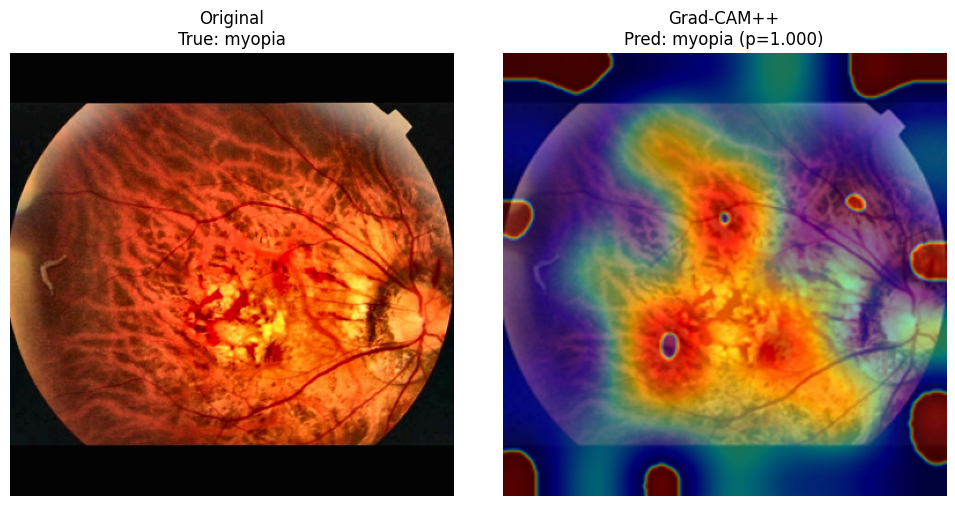

Done.


In [ ]:
# ONE CELL — FCNN prediction (91.8% pipeline) + Grad-CAM++ + clinical feature importance

import os, numpy as np, pandas as pd, joblib, torch, torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torchvision import models, transforms
from pathlib import Path
from PIL import Image
import cv2, matplotlib.pyplot as plt, matplotlib.cm as cm

# ========= PATHS (EDIT IF NEEDED) =========
MERGED_CSV     = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/merged_fundus_features.csv"
EXP_DIR        = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240"
FCNN_CKPT      = os.path.join(EXP_DIR, "fold2_FCNN_deep/FCNN_deep_fold2_best.pth")
SCALER_PATH    = os.path.join(EXP_DIR, "scaler.joblib")
RESNET_CKPT    = "/content/drive/MyDrive/Colab Notebooks/best_model_fold5.pth"
IMAGE_ROOT     = "/content/drive/MyDrive/Colab Notebooks/dataset_final_split"
OUT_DIR        = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/explainability"
os.makedirs(OUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ========= LOAD DATAFRAME & BUILD FEATURES AS IN TRAINING =========
df = pd.read_csv(MERGED_CSV, low_memory=False)
print("Raw shape:", df.shape)

if "label_idx" not in df.columns:
    raise KeyError("label_idx column not found")
df = df[~df['label_idx'].isna()].reset_index(drop=True)
df['label_idx'] = df['label_idx'].astype(int)

CLASS_NAMES = ['hr','myopia','normal','rp']
NUM_CLASSES = len(CLASS_NAMES)

emb_cols = [c for c in df.columns if c.startswith("emb_")]
exclude_cols = set(['image_path','image_id','checkpoint_path','label_name','split'])
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
extra_numeric = [c for c in numeric_cols if (c not in emb_cols and c not in exclude_cols and c!='label_idx')]
FEATURE_COLS = emb_cols + extra_numeric
emb_dim = len(emb_cols)
clin_dim = len(extra_numeric)
input_dim = len(FEATURE_COLS)
print(f"Using {emb_dim} emb_* + {clin_dim} numeric -> {input_dim} features")

# Preprocess features exactly like training
X_df = df[FEATURE_COLS].copy()
X_df.replace([np.inf, -np.inf], np.nan, inplace=True)
means = X_df.mean()
X_df = X_df.fillna(means).fillna(0.0)
if np.isinf(X_df.values).any() or np.isnan(X_df.values).any():
    X_df = X_df.replace([np.inf, -np.inf], 0.0).fillna(0.0)

# Load scaler and build scaled matrix
scaler = joblib.load(SCALER_PATH)
X_all = scaler.transform(X_df.values)
y_all = df['label_idx'].astype(int).values
print("X_all shape:", X_all.shape, " y_all:", y_all.shape)

# Build test subset with link to original index
if 'split' in df.columns:
    df_test = df[df['split']=='test'].copy()
else:
    df_test = df.copy()
df_test = df_test.reset_index().rename(columns={'index':'orig_idx'})
print("Test rows:", len(df_test))

# ========= FCNN (SAME ARCH AS TRAINING) =========
class FCNN_deep(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 2048)
        self.bn1 = nn.BatchNorm1d(2048)
        self.fc2 = nn.Linear(2048, 1024)
        self.fc3 = nn.Linear(1024, 512)
        self.out = nn.Linear(512, num_classes)
        self.drop = nn.Dropout(0.4)
    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.drop(x)
        x = F.relu(self.fc2(x))
        x = self.drop(x)
        x = F.relu(self.fc3(x))
        x = self.drop(x)
        return self.out(x)

fcnn = FCNN_deep(input_dim, NUM_CLASSES).to(device)
state_dict = torch.load(FCNN_CKPT, map_location=device)
fcnn.load_state_dict(state_dict, strict=True)
fcnn.eval()
print("Loaded FCNN_deep from:", FCNN_CKPT)

# ========= RESNET FEATURE EXTRACTOR (SAME AS EMBEDDING SCRIPT) =========
def _strip_prefixes(state_dict):
    new_sd = {}
    for k, v in state_dict.items():
        nk = k
        for pref in ["module.", "model."]:
            if nk.startswith(pref):
                nk = nk[len(pref):]
        new_sd[nk] = v
    return new_sd

def load_resnet18_as_feature_extractor(checkpoint_path: str) -> nn.Module:
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(512, 4)  # temp head
    ckpt = torch.load(checkpoint_path, map_location="cpu")

    if isinstance(ckpt, dict) and any(k in ckpt for k in ["state_dict","model_state_dict"]):
        state_dict = ckpt.get("state_dict", ckpt.get("model_state_dict"))
        state_dict = _strip_prefixes(state_dict)
        missing, unexpected = model.load_state_dict(state_dict, strict=False)
        print("ResNet missing keys:", missing)
        print("ResNet unexpected keys:", unexpected)
    elif isinstance(ckpt, dict):
        state_dict = _strip_prefixes(ckpt)
        missing, unexpected = model.load_state_dict(state_dict, strict=False)
        print("ResNet missing keys:", missing)
        print("ResNet unexpected keys:", unexpected)
    else:
        model = ckpt
        print("Loaded entire model object.")

    model.fc = nn.Identity()   # output 512-D
    model.eval()
    model.to(device)
    return model

resnet = load_resnet18_as_feature_extractor(RESNET_CKPT)

# ========= SCALER PARAMS AS TORCH TENSORS =========
mean_full = torch.tensor(scaler.mean_, dtype=torch.float32, device=device).unsqueeze(0)
scale_full = torch.tensor(scaler.scale_, dtype=torch.float32, device=device).unsqueeze(0)

# ========= TFMS & HELPERS =========
inference_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def find_image_path(image_id_or_path):
    p = Path(image_id_or_path)
    if p.exists():
        return str(p)
    if 'image_path' in df.columns:
        m = df[df['image_path'] == image_id_or_path]
        if len(m):
            return m.iloc[0]['image_path']
    for sp in ['train','val','test']:
        for cls in CLASS_NAMES:
            d = Path(IMAGE_ROOT)/sp/cls
            if d.exists():
                files = list(d.glob(f"{image_id_or_path}*"))
                if files:
                    return str(files[0])
    for p in Path(IMAGE_ROOT).rglob(f"*{image_id_or_path}*"):
        return str(p)
    return None

# ========= MAIN GRAD-CAM++ FUNCTION =========
def gradcam_pp_for_sample(test_idx):
    row = df_test.iloc[test_idx]
    orig_idx = int(row['orig_idx'])
    img_id = row['image_id']
    true_idx = int(row['label_idx'])
    true_name = CLASS_NAMES[true_idx]

    img_path = find_image_path(img_id)
    if img_path is None:
        raise RuntimeError(f"Image not found for id {img_id}")
    print("Using image:", img_path)

    # reconstruct raw clinical values from scaled features
    S_full = X_all[orig_idx]              # scaled feature vector
    S_emb = S_full[:emb_dim]
    S_clin = S_full[emb_dim:]
    mean_np = scaler.mean_
    scale_np = scaler.scale_
    mean_clin = mean_np[emb_dim:]
    scale_clin = scale_np[emb_dim:]
    clin_raw = S_clin * scale_clin + mean_clin

    clin_raw_t = torch.tensor(clin_raw, dtype=torch.float32, device=device).unsqueeze(0)

    # load & preprocess image
    pil = Image.open(img_path).convert('RGB')
    img_t = inference_tfms(pil).unsqueeze(0).to(device)

    # hooks for Grad-CAM++
    activations = None
    gradients = None
    target_layer = resnet.layer4[-1].conv2

    def fwd_hook(m, i, o):
        nonlocal activations
        activations = o
    def bwd_hook(m, gin, gout):
        nonlocal gradients
        gradients = gout[0]

    h1 = target_layer.register_forward_hook(fwd_hook)
    h2 = target_layer.register_full_backward_hook(bwd_hook)

    # forward through resnet
    x = img_t
    x = resnet.conv1(x); x = resnet.bn1(x); x = resnet.relu(x); x = resnet.maxpool(x)
    x = resnet.layer1(x); x = resnet.layer2(x); x = resnet.layer3(x); x = resnet.layer4(x)
    x_pool = resnet.avgpool(x)
    emb_raw = torch.flatten(x_pool, 1)    # (1, emb_dim)

    # concat raw emb + clinical, then standardize with same scaler
    full_raw = torch.cat([emb_raw, clin_raw_t], dim=1)  # (1, input_dim)
    full_scaled = (full_raw - mean_full) / (scale_full + 1e-6)

    # FCNN prediction
    out = fcnn(full_scaled)
    probs = torch.softmax(out, dim=1).detach().cpu().numpy().squeeze()
    pred_idx = int(np.argmax(probs))
    pred_name = CLASS_NAMES[pred_idx]
    pred_prob = float(probs[pred_idx])

    print(f"Prediction: {pred_name} (p={pred_prob:.3f})   |   True: {true_name}")

    # backward for Grad-CAM++
    score = out[0, pred_idx]
    fcnn.zero_grad(); resnet.zero_grad()
    score.backward(retain_graph=True)

    h1.remove(); h2.remove()

    # Grad-CAM++ map
    A = activations.detach()[0]   # (C,H,W)
    G = gradients.detach()[0]     # (C,H,W)
    eps = 1e-9
    alpha_num = G.pow(2)
    alpha_denom = 2 * G.pow(2) + (A * G.pow(3)).sum(dim=(1,2), keepdim=True)
    alpha = alpha_num / (alpha_denom + eps)
    weights = (alpha * torch.relu(G)).sum(dim=(1,2))
    cam = torch.relu((weights[:, None, None] * A).sum(dim=0))
    cam_np = cam.detach().cpu().numpy()
    cam_np = (cam_np - cam_np.min()) / (cam_np.max() - cam_np.min() + 1e-9)
    cam_up = cv2.resize(cam_np, (224,224), interpolation=cv2.INTER_CUBIC)
    cam_up = cv2.GaussianBlur((cam_up*255).astype('uint8'), (5,5), 1.0).astype(np.float32)/255.0

    # overlay → PIL image
    base = np.array(pil.resize((224,224)).convert("RGB")).astype(np.float32)/255.0
    cmap = cm.get_cmap('jet')
    heat = cmap(cam_up)[...,:3]
    alpha_overlay = 0.45
    blended = (1.0-alpha_overlay)*base + alpha_overlay*heat
    blended = np.clip(blended, 0, 1)

    out_img = (blended*255).astype(np.uint8)
    cam_pil = Image.fromarray(out_img)

    out_path = os.path.join(OUT_DIR, f"{Path(img_path).stem}_GradCAMpp_fusion.png")
    cam_pil.save(out_path, format='PNG', compress_level=1)
    print("Saved Grad-CAM++ overlay to:", out_path)

    # clinical feature importance from FCNN (on scaled features)
    full_scaled_t = full_scaled.clone().detach().requires_grad_(True)
    out2 = fcnn(full_scaled_t)
    score2 = out2[0, pred_idx]
    fcnn.zero_grad()
    score2.backward()
    grads_feat = full_scaled_t.grad.detach().cpu().numpy().squeeze()
    clin_grads = grads_feat[emb_dim:]     # only clinical part
    signs = np.sign(clin_grads)
    imps = np.abs(clin_grads)

    top_idx = np.argsort(imps)[::-1][:5]
    print("\nTop clinical features (name, influence, scaled_grad):")
    for i in top_idx:
        fname = extra_numeric[i]
        s = '+' if signs[i]>0 else '-' if signs[i]<0 else '0'
        print(" -", fname, ("increase" if s=='+' else "decrease" if s=='-' else "nochange"),
              "importance=", round(imps[i],6))

    # show side-by-side
    fig, ax = plt.subplots(1,2, figsize=(10,5))
    ax[0].imshow(pil.resize((384,384)))
    ax[0].set_title(f"Original\nTrue: {true_name}")
    ax[0].axis('off')

    ax[1].imshow(cam_pil.resize((384,384)))
    ax[1].set_title(f"Grad-CAM++\nPred: {pred_name} (p={pred_prob:.3f})")
    ax[1].axis('off')
    plt.tight_layout()
    plt.show()

    return pred_idx, pred_prob, true_idx

# ========= RUN EXPLANATION FOR ONE TEST SAMPLE =========
test_idx = 160   # change this index to inspect other test images
_ = gradcam_pp_for_sample(test_idx)

print("Done.")


In [ ]:
# ===== EVALUATION FOR RESNET + FCNN + SCALER FUSION PIPELINE =====
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def eval_fusion_pipeline():
    y_true, y_pred, used_ids = [], [], []

    mean_np = scaler.mean_
    scale_np = scaler.scale_
    mean_clin = mean_np[emb_dim:]
    scale_clin = scale_np[emb_dim:]

    for idx, row in df_test.iterrows():
        orig_idx = int(row['orig_idx'])
        img_id   = row['image_id']
        true_idx = int(row['label_idx'])

        img_path = find_image_path(img_id)
        if img_path is None:
            continue

        # --- clinical raw values reconstructed from scaled features ---
        S_full = X_all[orig_idx]          # scaled feature vector
        S_clin = S_full[emb_dim:]
        clin_raw = S_clin * scale_clin + mean_clin
        clin_raw_t = torch.tensor(clin_raw, dtype=torch.float32, device=device).unsqueeze(0)

        # --- image -> embedding from ResNet ---
        pil = Image.open(img_path).convert('RGB')
        img_t = inference_tfms(pil).unsqueeze(0).to(device)

        with torch.no_grad():
            x = img_t
            x = resnet.conv1(x); x = resnet.bn1(x); x = resnet.relu(x); x = resnet.maxpool(x)
            x = resnet.layer1(x); x = resnet.layer2(x); x = resnet.layer3(x); x = resnet.layer4(x)
            x_pool = resnet.avgpool(x)
            emb_raw = torch.flatten(x_pool, 1)   # (1, emb_dim)

            # concat emb + clin, then standardize with SAME scaler
            full_raw = torch.cat([emb_raw, clin_raw_t], dim=1)  # (1, input_dim)
            full_scaled = (full_raw - mean_full) / (scale_full + 1e-6)

            logits = fcnn(full_scaled)
            probs = torch.softmax(logits, dim=1)
            pred_idx = int(torch.argmax(probs, dim=1).item())

        y_true.append(true_idx)
        y_pred.append(pred_idx)
        used_ids.append(img_id)

    y_true_arr = np.array(y_true)
    y_pred_arr = np.array(y_pred)

    print("Samples used:", len(y_true_arr))
    acc = accuracy_score(y_true_arr, y_pred_arr)
    print(f"\nFusion pipeline accuracy: {acc:.4f}\n")

    print("Classification report:")
    print(classification_report(y_true_arr, y_pred_arr, target_names=CLASS_NAMES))

    print("Confusion matrix (rows=true, cols=pred):")
    print(confusion_matrix(y_true_arr, y_pred_arr))

    # optional: save per-image preds
    pred_df = pd.DataFrame({
        "image_id": used_ids,
        "true_idx": y_true_arr,
        "true_label": [CLASS_NAMES[i] for i in y_true_arr],
        "pred_idx": y_pred_arr,
        "pred_label": [CLASS_NAMES[i] for i in y_pred_arr],
    })
    out_csv = os.path.join(OUT_DIR, "fusion_pipeline_eval_predictions.csv")
    pred_df.to_csv(out_csv, index=False)
    print("\nSaved per-image predictions to:", out_csv)

# run it
eval_fusion_pipeline()


Samples used: 1027

Fusion pipeline accuracy: 0.9182

Classification report:
              precision    recall  f1-score   support

          hr       0.56      0.84      0.67        79
      myopia       0.97      0.98      0.97       380
      normal       0.95      0.84      0.89       399
          rp       1.00      1.00      1.00       169

    accuracy                           0.92      1027
   macro avg       0.87      0.91      0.88      1027
weighted avg       0.93      0.92      0.92      1027

Confusion matrix (rows=true, cols=pred):
[[ 66   0  13   0]
 [  1 373   6   0]
 [ 51  13 335   0]
 [  0   0   0 169]]

Saved per-image predictions to: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/explainability/fusion_pipeline_eval_predictions.csv


In [ ]:
# ONE CELL — FCNN prediction (91.8% pipeline) + Grad-CAM++ + clinical feature importance

import os, numpy as np, pandas as pd, joblib, torch, torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torchvision import models, transforms
from pathlib import Path
from PIL import Image
import cv2, matplotlib.pyplot as plt, matplotlib.cm as cm

# ========= PATHS (EDIT IF NEEDED) =========
MERGED_CSV     = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/merged_fundus_features.csv"
EXP_DIR        = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240"
FCNN_CKPT      = os.path.join(EXP_DIR, "fold2_FCNN_deep/FCNN_deep_fold2_best.pth")
SCALER_PATH    = os.path.join(EXP_DIR, "scaler.joblib")
RESNET_CKPT    = "/content/drive/MyDrive/Colab Notebooks/best_model_fold5.pth"
IMAGE_ROOT     = "/content/drive/MyDrive/Colab Notebooks/dataset_final_split"
OUT_DIR        = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/explainability"
os.makedirs(OUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ========= LOAD DATAFRAME & BUILD FEATURES AS IN TRAINING =========
df = pd.read_csv(MERGED_CSV, low_memory=False)
print("Raw shape:", df.shape)

if "label_idx" not in df.columns:
    raise KeyError("label_idx column not found")
df = df[~df['label_idx'].isna()].reset_index(drop=True)
df['label_idx'] = df['label_idx'].astype(int)

CLASS_NAMES = ['hr','myopia','normal','rp']
NUM_CLASSES = len(CLASS_NAMES)

emb_cols = [c for c in df.columns if c.startswith("emb_")]
exclude_cols = set(['image_path','image_id','checkpoint_path','label_name','split'])
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
extra_numeric = [c for c in numeric_cols if (c not in emb_cols and c not in exclude_cols and c!='label_idx')]
FEATURE_COLS = emb_cols + extra_numeric
emb_dim = len(emb_cols)
clin_dim = len(extra_numeric)
input_dim = len(FEATURE_COLS)
print(f"Using {emb_dim} emb_* + {clin_dim} numeric -> {input_dim} features")

# Preprocess features exactly like training
X_df = df[FEATURE_COLS].copy()
X_df.replace([np.inf, -np.inf], np.nan, inplace=True)
means = X_df.mean()
X_df = X_df.fillna(means).fillna(0.0)
if np.isinf(X_df.values).any() or np.isnan(X_df.values).any():
    X_df = X_df.replace([np.inf, -np.inf], 0.0).fillna(0.0)

# Load scaler and build scaled matrix
scaler = joblib.load(SCALER_PATH)
X_all = scaler.transform(X_df.values)
y_all = df['label_idx'].astype(int).values
print("X_all shape:", X_all.shape, " y_all:", y_all.shape)

# Build test subset with link to original index
if 'split' in df.columns:
    df_test = df[df['split']=='test'].copy()
else:
    df_test = df.copy()
df_test = df_test.reset_index().rename(columns={'index':'orig_idx'})
print("Test rows:", len(df_test))

# ========= FCNN (SAME ARCH AS TRAINING) =========
class FCNN_deep(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 2048)
        self.bn1 = nn.BatchNorm1d(2048)
        self.fc2 = nn.Linear(2048, 1024)
        self.fc3 = nn.Linear(1024, 512)
        self.out = nn.Linear(512, num_classes)
        self.drop = nn.Dropout(0.4)
    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.drop(x)
        x = F.relu(self.fc2(x))
        x = self.drop(x)
        x = F.relu(self.fc3(x))
        x = self.drop(x)
        return self.out(x)

fcnn = FCNN_deep(input_dim, NUM_CLASSES).to(device)
state_dict = torch.load(FCNN_CKPT, map_location=device)
fcnn.load_state_dict(state_dict, strict=True)
fcnn.eval()
print("Loaded FCNN_deep from:", FCNN_CKPT)

# ========= RESNET FEATURE EXTRACTOR (SAME AS EMBEDDING SCRIPT) =========
def _strip_prefixes(state_dict):
    new_sd = {}
    for k, v in state_dict.items():
        nk = k
        for pref in ["module.", "model."]:
            if nk.startswith(pref):
                nk = nk[len(pref):]
        new_sd[nk] = v
    return new_sd

def load_resnet18_as_feature_extractor(checkpoint_path: str) -> nn.Module:
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(512, 4)  # temp head
    ckpt = torch.load(checkpoint_path, map_location="cpu")

    if isinstance(ckpt, dict) and any(k in ckpt for k in ["state_dict","model_state_dict"]):
        state_dict = ckpt.get("state_dict", ckpt.get("model_state_dict"))
        state_dict = _strip_prefixes(state_dict)
        missing, unexpected = model.load_state_dict(state_dict, strict=False)
        print("ResNet missing keys:", missing)
        print("ResNet unexpected keys:", unexpected)
    elif isinstance(ckpt, dict):
        state_dict = _strip_prefixes(ckpt)
        missing, unexpected = model.load_state_dict(state_dict, strict=False)
        print("ResNet missing keys:", missing)
        print("ResNet unexpected keys:", unexpected)
    else:
        model = ckpt
        print("Loaded entire model object.")

    model.fc = nn.Identity()   # output 512-D
    model.eval()
    model.to(device)
    return model

resnet = load_resnet18_as_feature_extractor(RESNET_CKPT)

# ========= SCALER PARAMS AS TORCH TENSORS =========
mean_full = torch.tensor(scaler.mean_, dtype=torch.float32, device=device).unsqueeze(0)
scale_full = torch.tensor(scaler.scale_, dtype=torch.float32, device=device).unsqueeze(0)

# ========= TFMS & HELPERS =========
inference_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def find_image_path(image_id_or_path):
    p = Path(image_id_or_path)
    if p.exists():
        return str(p)
    if 'image_path' in df.columns:
        m = df[df['image_path'] == image_id_or_path]
        if len(m):
            return m.iloc[0]['image_path']
    for sp in ['train','val','test']:
        for cls in CLASS_NAMES:
            d = Path(IMAGE_ROOT)/sp/cls
            if d.exists():
                files = list(d.glob(f"{image_id_or_path}*"))
                if files:
                    return str(files[0])
    for p in Path(IMAGE_ROOT).rglob(f"*{image_id_or_path}*"):
        return str(p)
    return None

# ========= MAIN GRAD-CAM++ FUNCTION =========
def gradcam_pp_for_sample(test_idx):
    row = df_test.iloc[test_idx]
    orig_idx = int(row['orig_idx'])
    img_id = row['image_id']
    true_idx = int(row['label_idx'])
    true_name = CLASS_NAMES[true_idx]

    img_path = find_image_path(img_id)
    if img_path is None:
        raise RuntimeError(f"Image not found for id {img_id}")
    print("Using image:", img_path)

    # reconstruct raw clinical values from scaled features
    S_full = X_all[orig_idx]              # scaled feature vector
    S_emb = S_full[:emb_dim]
    S_clin = S_full[emb_dim:]
    mean_np = scaler.mean_
    scale_np = scaler.scale_
    mean_clin = mean_np[emb_dim:]
    scale_clin = scale_np[emb_dim:]
    clin_raw = S_clin * scale_clin + mean_clin

    clin_raw_t = torch.tensor(clin_raw, dtype=torch.float32, device=device).unsqueeze(0)

    # load & preprocess image
    pil = Image.open(img_path).convert('RGB')
    img_t = inference_tfms(pil).unsqueeze(0).to(device)

    # hooks for Grad-CAM++
    activations = None
    gradients = None
    target_layer = resnet.layer4[-1].conv2

    def fwd_hook(m, i, o):
        nonlocal activations
        activations = o
    def bwd_hook(m, gin, gout):
        nonlocal gradients
        gradients = gout[0]

    h1 = target_layer.register_forward_hook(fwd_hook)
    h2 = target_layer.register_full_backward_hook(bwd_hook)

    # forward through resnet
    x = img_t
    x = resnet.conv1(x); x = resnet.bn1(x); x = resnet.relu(x); x = resnet.maxpool(x)
    x = resnet.layer1(x); x = resnet.layer2(x); x = resnet.layer3(x); x = resnet.layer4(x)
    x_pool = resnet.avgpool(x)
    emb_raw = torch.flatten(x_pool, 1)    # (1, emb_dim)

    # concat raw emb + clinical, then standardize with same scaler
    full_raw = torch.cat([emb_raw, clin_raw_t], dim=1)  # (1, input_dim)
    full_scaled = (full_raw - mean_full) / (scale_full + 1e-6)

    # FCNN prediction
    out = fcnn(full_scaled)
    probs = torch.softmax(out, dim=1).detach().cpu().numpy().squeeze()
    pred_idx = int(np.argmax(probs))
    pred_name = CLASS_NAMES[pred_idx]
    pred_prob = float(probs[pred_idx])

    print(f"Prediction: {pred_name} (p={pred_prob:.3f})   |   True: {true_name}")

    # backward for Grad-CAM++
    score = out[0, pred_idx]
    fcnn.zero_grad(); resnet.zero_grad()
    score.backward(retain_graph=True)

    h1.remove(); h2.remove()

    # Grad-CAM++ map
    A = activations.detach()[0]   # (C,H,W)
    G = gradients.detach()[0]     # (C,H,W)
    eps = 1e-9
    alpha_num = G.pow(2)
    alpha_denom = 2 * G.pow(2) + (A * G.pow(3)).sum(dim=(1,2), keepdim=True)
    alpha = alpha_num / (alpha_denom + eps)
    weights = (alpha * torch.relu(G)).sum(dim=(1,2))
    cam = torch.relu((weights[:, None, None] * A).sum(dim=0))
    cam_np = cam.detach().cpu().numpy()
    cam_np = (cam_np - cam_np.min()) / (cam_np.max() - cam_np.min() + 1e-9)
    cam_up = cv2.resize(cam_np, (224,224), interpolation=cv2.INTER_CUBIC)
    cam_up = cv2.GaussianBlur((cam_up*255).astype('uint8'), (5,5), 1.0).astype(np.float32)/255.0

    # overlay → PIL image
    base = np.array(pil.resize((224,224)).convert("RGB")).astype(np.float32)/255.0
    cmap = cm.get_cmap('jet')
    heat = cmap(cam_up)[...,:3]
    alpha_overlay = 0.45
    blended = (1.0-alpha_overlay)*base + alpha_overlay*heat
    blended = np.clip(blended, 0, 1)

    out_img = (blended*255).astype(np.uint8)
    cam_pil = Image.fromarray(out_img)

    out_path = os.path.join(OUT_DIR, f"{Path(img_path).stem}_GradCAMpp_fusion.png")
    cam_pil.save(out_path, format='PNG', compress_level=1)
    print("Saved Grad-CAM++ overlay to:", out_path)

    # clinical feature importance from FCNN (on scaled features)
    full_scaled_t = full_scaled.clone().detach().requires_grad_(True)
    out2 = fcnn(full_scaled_t)
    score2 = out2[0, pred_idx]
    fcnn.zero_grad()
    score2.backward()
    grads_feat = full_scaled_t.grad.detach().cpu().numpy().squeeze()
    clin_grads = grads_feat[emb_dim:]     # only clinical part
    signs = np.sign(clin_grads)
    imps = np.abs(clin_grads)

    top_idx = np.argsort(imps)[::-1][:5]
    print("\nTop clinical features (name, influence, scaled_grad):")
    for i in top_idx:
        fname = extra_numeric[i]
        s = '+' if signs[i]>0 else '-' if signs[i]<0 else '0'
        print(" -", fname, ("increase" if s=='+' else "decrease" if s=='-' else "nochange"),
              "importance=", round(imps[i],6))

    # show side-by-side
    fig, ax = plt.subplots(1,2, figsize=(10,5))
    ax[0].imshow(pil.resize((384,384)))
    ax[0].set_title(f"Original\nTrue: {true_name}")
    ax[0].axis('off')

    ax[1].imshow(cam_pil.resize((384,384)))
    ax[1].set_title(f"Grad-CAM++\nPred: {pred_name} (p={pred_prob:.3f})")
    ax[1].axis('off')
    plt.tight_layout()
    plt.show()

    return pred_idx, pred_prob, true_idx

# ========= RUN EXPLANATION FOR ONE TEST SAMPLE =========
for test_idx in [10, 400, 750, 1000]:
    print("\n=== test_idx:", test_idx, "===")
    _ = gradcam_pp_for_sample(test_idx)
print("Done.")


Output hidden; open in https://colab.research.google.com to view.

 Fusion Model Evaluation Results
Overall Accuracy: 0.9182

Classification Report:
              precision    recall  f1-score   support

          hr       0.56      0.84      0.67        79
      myopia       0.97      0.98      0.97       380
      normal       0.95      0.84      0.89       399
          rp       1.00      1.00      1.00       169

    accuracy                           0.92      1027
   macro avg       0.87      0.91      0.88      1027
weighted avg       0.93      0.92      0.92      1027


Confusion Matrix:
[[ 66   0  13   0]
 [  1 373   6   0]
 [ 51  13 335   0]
 [  0   0   0 169]]

Saved per-image results to:
/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/explainability/fusion_evaluation_predictions.csv


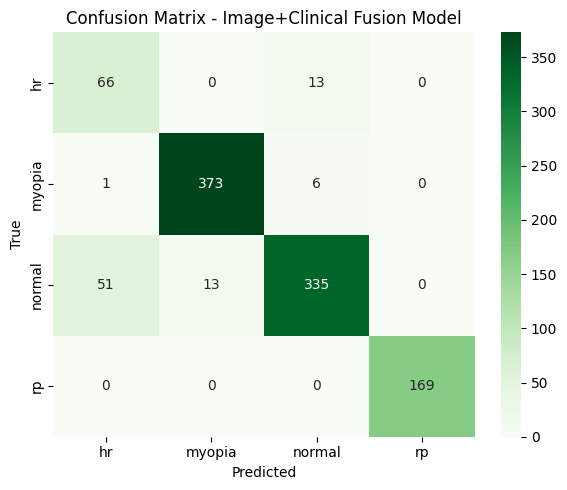

Saved confusion matrix image to:
/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/explainability/fusion_confusion_matrix.png


In [ ]:
# ==========================================================
# FINAL EVALUATION CELL (for thesis / research article)
# ==========================================================

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_fusion_pipeline():
    y_true, y_pred, img_ids = [], [], []

    mean_np = scaler.mean_
    scale_np = scaler.scale_
    mean_clin = mean_np[emb_dim:]
    scale_clin = scale_np[emb_dim:]

    for idx, row in df_test.iterrows():
        orig_idx = int(row['orig_idx'])
        img_id   = row['image_id']
        true_idx = int(row['label_idx'])

        img_path = find_image_path(img_id)
        if img_path is None:
            continue

        # clinical reconstruction
        S_full = X_all[orig_idx]
        S_clin = S_full[emb_dim:]
        clin_raw = S_clin * scale_clin + mean_clin
        clin_raw_t = torch.tensor(clin_raw, dtype=torch.float32, device=device).unsqueeze(0)

        # get ResNet embedding
        pil = Image.open(img_path).convert('RGB')
        img_t = inference_tfms(pil).unsqueeze(0).to(device)
        with torch.no_grad():
            x = img_t
            x = resnet.conv1(x); x = resnet.bn1(x); x = resnet.relu(x); x = resnet.maxpool(x)
            x = resnet.layer1(x); x = resnet.layer2(x); x = resnet.layer3(x); x = resnet.layer4(x)
            x_pool = resnet.avgpool(x)
            emb_raw = torch.flatten(x_pool, 1)

            # fusion + prediction
            full_raw = torch.cat([emb_raw, clin_raw_t], dim=1)
            full_scaled = (full_raw - mean_full) / (scale_full + 1e-6)
            logits = fcnn(full_scaled)
            probs = torch.softmax(logits, dim=1)
            pred_idx = int(torch.argmax(probs, dim=1).item())

        y_true.append(true_idx)
        y_pred.append(pred_idx)
        img_ids.append(img_id)

    # Convert arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Compute and print metrics
    print("=========================================")
    print(" Fusion Model Evaluation Results")
    print("=========================================")
    acc = accuracy_score(y_true, y_pred)
    print(f"Overall Accuracy: {acc:.4f}\n")

    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:")
    print(cm)

    # save predictions
    results_df = pd.DataFrame({
        "image_id": img_ids,
        "true_label_idx": y_true,
        "true_label": [CLASS_NAMES[i] for i in y_true],
        "pred_label_idx": y_pred,
        "pred_label": [CLASS_NAMES[i] for i in y_pred]
    })
    results_path = os.path.join(OUT_DIR, "fusion_evaluation_predictions.csv")
    results_df.to_csv(results_path, index=False)
    print(f"\nSaved per-image results to:\n{results_path}")

    # save confusion matrix image
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix - Image+Clinical Fusion Model")
    cm_img_path = os.path.join(OUT_DIR, "fusion_confusion_matrix.png")
    plt.tight_layout()
    plt.savefig(cm_img_path)
    plt.show()
    print(f"Saved confusion matrix image to:\n{cm_img_path}")

    return acc, cm, results_df

# ==== RUN EVALUATION ====
acc, cm, results_df = evaluate_fusion_pipeline()


Device: cpu
Raw shape: (5555, 640)
Using 512 emb_* + 118 numeric -> 630 features
X_all shape: (5555, 630)  y_all: (5555,)
Test rows: 1027
Loaded FCNN_deep from: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240/fold2_FCNN_deep/FCNN_deep_fold2_best.pth
ResNet missing keys: []
ResNet unexpected keys: []

=== test_idx: 10 ===
Using image: /content/drive/MyDrive/Colab Notebooks/dataset_final_split/test/hr/0709(NFMK2).jpg
Prediction: hr (p=0.507)   |   True: hr


/tmp/ipython-input-2095245225.py:248: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('jet')


Saved Grad-CAM++ overlay to: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/explainability/0709(NFMK2)_GradCAMpp_fusion.png

Top clinical features (name, influence, scaled_grad):
 - 1. vein_density_generic (decrease) importance= 0.213202
 - 2. vein_density (decrease) importance= 0.210323
 - 3. illumination_gradient_x (increase) importance= 0.198194
 - 4. macular_entropy_y (increase) importance= 0.192526
 - 5. illumination_gradient_x_generic (increase) importance= 0.190221


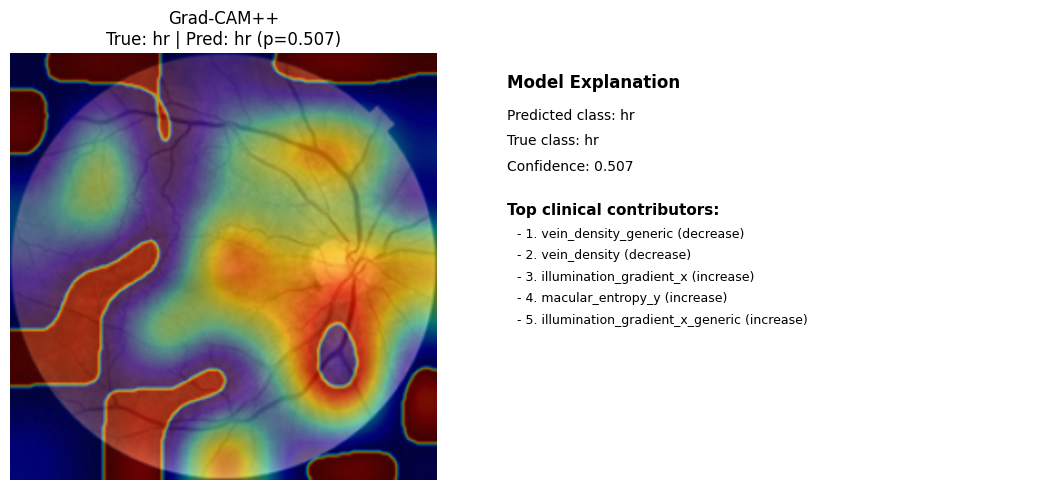

Saved Grad-CAM++ + text panel: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/explainability/0709(NFMK2)_GradCAMpp_panel.png

=== test_idx: 400 ===
Using image: /content/drive/MyDrive/Colab Notebooks/dataset_final_split/test/myopia/3662(SLFY28).JPG
Prediction: myopia (p=1.000)   |   True: myopia
Saved Grad-CAM++ overlay to: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/explainability/3662(SLFY28)_GradCAMpp_fusion.png

Top clinical features (name, influence, scaled_grad):
 - 1. vessel_density (decrease) importance= 0.344854
 - 2. vein_density (increase) importance= 0.340743
 - 3. vein_density_generic (increase) importance= 0.340701
 - 4. hard_exudate_max_area (increase) importance= 0.272797
 - 5. hard_exudate_max_area_generic (increase) importance= 0.263501


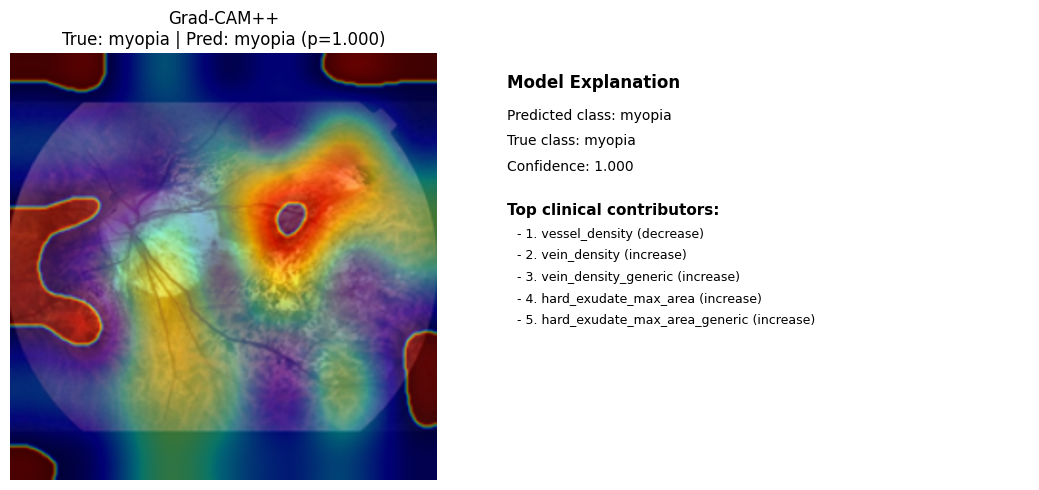

Saved Grad-CAM++ + text panel: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/explainability/3662(SLFY28)_GradCAMpp_panel.png

=== test_idx: 750 ===
Using image: /content/drive/MyDrive/Colab Notebooks/dataset_final_split/test/normal/3154(ZDSG5).jpg
Prediction: normal (p=0.777)   |   True: normal
Saved Grad-CAM++ overlay to: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/explainability/3154(ZDSG5)_GradCAMpp_fusion.png

Top clinical features (name, influence, scaled_grad):
 - 1. avg_lesion_aspect_ratio (increase) importance= 0.098893
 - 2. macular_intensity_ratio (increase) importance= 0.075148
 - 3. brightness_entropy_ratio (increase) importance= 0.074821
 - 4. macular_brightness (increase) importance= 0.071031
 - 5. AVR_generic (increase) importance= 0.066919


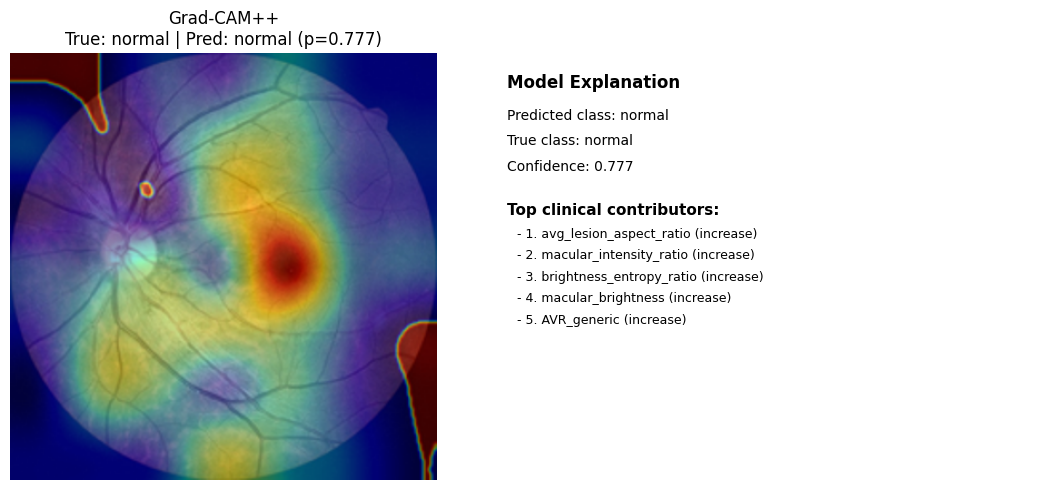

Saved Grad-CAM++ + text panel: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/explainability/3154(ZDSG5)_GradCAMpp_panel.png

=== test_idx: 1000 ===
Using image: /content/drive/MyDrive/Colab Notebooks/dataset_final_split/test/rp/Retinitis Pigmentosa69.png
Prediction: rp (p=1.000)   |   True: rp
Saved Grad-CAM++ overlay to: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/explainability/Retinitis Pigmentosa69_GradCAMpp_fusion.png

Top clinical features (name, influence, scaled_grad):
 - 1. color_red_mean_generic (increase) importance= 0.793167
 - 2. color_red_mean (increase) importance= 0.783095
 - 3. R_minus_G_mean (increase) importance= 0.649497
 - 4. R_minus_G_mean_generic (increase) importance= 0.637762
 - 5. color_balance_ratio (increase) importance= 0.566954


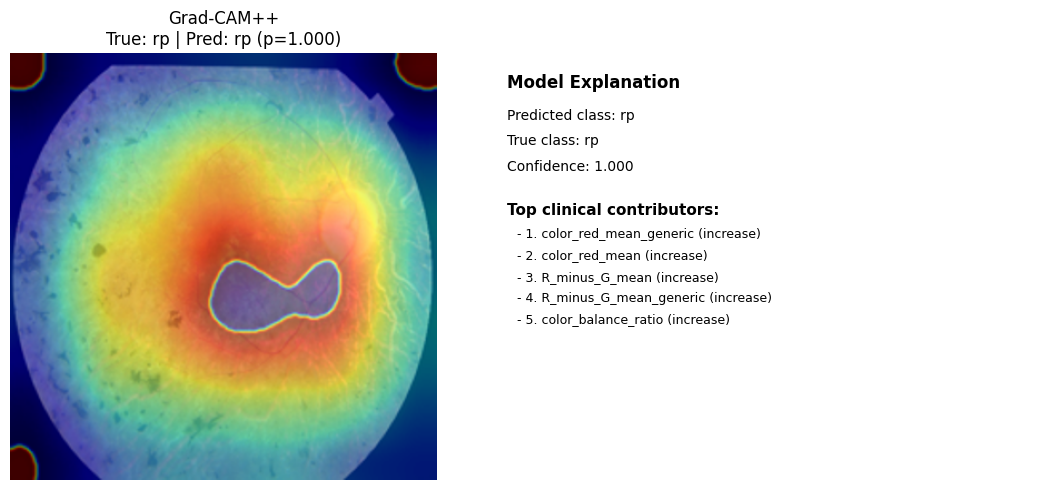

Saved Grad-CAM++ + text panel: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/explainability/Retinitis Pigmentosa69_GradCAMpp_panel.png
Done.


In [ ]:
# ONE CELL — FCNN prediction (91.8% pipeline) + Grad-CAM++ + clinical reasons in right-hand text panel

import os, numpy as np, pandas as pd, joblib, torch, torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torchvision import models, transforms
from pathlib import Path
from PIL import Image
import cv2, matplotlib.pyplot as plt, matplotlib.cm as cm

# ========= PATHS (EDIT IF NEEDED) =========
MERGED_CSV     = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/merged_fundus_features.csv"
EXP_DIR        = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240"
FCNN_CKPT      = os.path.join(EXP_DIR, "fold2_FCNN_deep/FCNN_deep_fold2_best.pth")
SCALER_PATH    = os.path.join(EXP_DIR, "scaler.joblib")
RESNET_CKPT    = "/content/drive/MyDrive/Colab Notebooks/best_model_fold5.pth"
IMAGE_ROOT     = "/content/drive/MyDrive/Colab Notebooks/dataset_final_split"
OUT_DIR        = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/explainability"
os.makedirs(OUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ========= LOAD DATAFRAME & BUILD FEATURES AS IN TRAINING =========
df = pd.read_csv(MERGED_CSV, low_memory=False)
print("Raw shape:", df.shape)

if "label_idx" not in df.columns:
    raise KeyError("label_idx column not found")
df = df[~df['label_idx'].isna()].reset_index(drop=True)
df['label_idx'] = df['label_idx'].astype(int)

CLASS_NAMES = ['hr','myopia','normal','rp']
NUM_CLASSES = len(CLASS_NAMES)

emb_cols = [c for c in df.columns if c.startswith("emb_")]
exclude_cols = set(['image_path','image_id','checkpoint_path','label_name','split'])
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
extra_numeric = [c for c in numeric_cols if (c not in emb_cols and c not in exclude_cols and c!='label_idx')]
FEATURE_COLS = emb_cols + extra_numeric
emb_dim = len(emb_cols)
clin_dim = len(extra_numeric)
input_dim = len(FEATURE_COLS)
print(f"Using {emb_dim} emb_* + {clin_dim} numeric -> {input_dim} features")

# Preprocess features exactly like training
X_df = df[FEATURE_COLS].copy()
X_df.replace([np.inf, -np.inf], np.nan, inplace=True)
means = X_df.mean()
X_df = X_df.fillna(means).fillna(0.0)
if np.isinf(X_df.values).any() or np.isnan(X_df.values).any():
    X_df = X_df.replace([np.inf, -np.inf], 0.0).fillna(0.0)

# Load scaler and build scaled matrix
scaler = joblib.load(SCALER_PATH)
X_all = scaler.transform(X_df.values)
y_all = df['label_idx'].astype(int).values
print("X_all shape:", X_all.shape, " y_all:", y_all.shape)

# Build test subset with link to original index
if 'split' in df.columns:
    df_test = df[df['split']=='test'].copy()
else:
    df_test = df.copy()
df_test = df_test.reset_index().rename(columns={'index':'orig_idx'})
print("Test rows:", len(df_test))

# ========= FCNN (SAME ARCH AS TRAINING) =========
class FCNN_deep(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 2048)
        self.bn1 = nn.BatchNorm1d(2048)
        self.fc2 = nn.Linear(2048, 1024)
        self.fc3 = nn.Linear(1024, 512)
        self.out = nn.Linear(512, num_classes)
        self.drop = nn.Dropout(0.4)
    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.drop(x)
        x = F.relu(self.fc2(x))
        x = self.drop(x)
        x = F.relu(self.fc3(x))
        x = self.drop(x)
        return self.out(x)

fcnn = FCNN_deep(input_dim, NUM_CLASSES).to(device)
state_dict = torch.load(FCNN_CKPT, map_location=device)
fcnn.load_state_dict(state_dict, strict=True)
fcnn.eval()
print("Loaded FCNN_deep from:", FCNN_CKPT)

# ========= RESNET FEATURE EXTRACTOR (SAME AS EMBEDDING SCRIPT) =========
def _strip_prefixes(state_dict):
    new_sd = {}
    for k, v in state_dict.items():
        nk = k
        for pref in ["module.", "model."]:
            if nk.startswith(pref):
                nk = nk[len(pref):]
        new_sd[nk] = v
    return new_sd

def load_resnet18_as_feature_extractor(checkpoint_path: str) -> nn.Module:
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(512, 4)  # temp head
    ckpt = torch.load(checkpoint_path, map_location="cpu")

    if isinstance(ckpt, dict) and any(k in ckpt for k in ["state_dict","model_state_dict"]):
        state_dict = ckpt.get("state_dict", ckpt.get("model_state_dict"))
        state_dict = _strip_prefixes(state_dict)
        missing, unexpected = model.load_state_dict(state_dict, strict=False)
        print("ResNet missing keys:", missing)
        print("ResNet unexpected keys:", unexpected)
    elif isinstance(ckpt, dict):
        state_dict = _strip_prefixes(ckpt)
        missing, unexpected = model.load_state_dict(state_dict, strict=False)
        print("ResNet missing keys:", missing)
        print("ResNet unexpected keys:", unexpected)
    else:
        model = ckpt
        print("Loaded entire model object.")

    model.fc = nn.Identity()   # output 512-D
    model.eval()
    model.to(device)
    return model

resnet = load_resnet18_as_feature_extractor(RESNET_CKPT)

# ========= SCALER PARAMS AS TORCH TENSORS =========
mean_full = torch.tensor(scaler.mean_, dtype=torch.float32, device=device).unsqueeze(0)
scale_full = torch.tensor(scaler.scale_, dtype=torch.float32, device=device).unsqueeze(0)

# ========= TFMS & HELPERS =========
inference_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def find_image_path(image_id_or_path):
    p = Path(image_id_or_path)
    if p.exists():
        return str(p)
    if 'image_path' in df.columns:
        m = df[df['image_path'] == image_id_or_path]
        if len(m):
            return m.iloc[0]['image_path']
    for sp in ['train','val','test']:
        for cls in CLASS_NAMES:
            d = Path(IMAGE_ROOT)/sp/cls
            if d.exists():
                files = list(d.glob(f"{image_id_or_path}*"))
                if files:
                    return str(files[0])
    for p in Path(IMAGE_ROOT).rglob(f"*{image_id_or_path}*"):
        return str(p)
    return None

# ========= MAIN GRAD-CAM++ FUNCTION (with right-hand text panel) =========
def gradcam_pp_for_sample(test_idx):
    row = df_test.iloc[test_idx]
    orig_idx = int(row['orig_idx'])
    img_id = row['image_id']
    true_idx = int(row['label_idx'])
    true_name = CLASS_NAMES[true_idx]

    img_path = find_image_path(img_id)
    if img_path is None:
        raise RuntimeError(f"Image not found for id {img_id}")
    print("Using image:", img_path)

    # reconstruct raw clinical values from scaled features
    S_full = X_all[orig_idx]              # scaled feature vector
    S_clin = S_full[emb_dim:]
    mean_np = scaler.mean_
    scale_np = scaler.scale_
    mean_clin = mean_np[emb_dim:]
    scale_clin = scale_np[emb_dim:]
    clin_raw = S_clin * scale_clin + mean_clin

    clin_raw_t = torch.tensor(clin_raw, dtype=torch.float32, device=device).unsqueeze(0)

    # load & preprocess image
    pil = Image.open(img_path).convert('RGB')
    img_t = inference_tfms(pil).unsqueeze(0).to(device)

    # hooks for Grad-CAM++
    activations = None
    gradients = None
    target_layer = resnet.layer4[-1].conv2

    def fwd_hook(m, i, o):
        nonlocal activations
        activations = o
    def bwd_hook(m, gin, gout):
        nonlocal gradients
        gradients = gout[0]

    h1 = target_layer.register_forward_hook(fwd_hook)
    h2 = target_layer.register_full_backward_hook(bwd_hook)

    # forward through resnet
    x = img_t
    x = resnet.conv1(x); x = resnet.bn1(x); x = resnet.relu(x); x = resnet.maxpool(x)
    x = resnet.layer1(x); x = resnet.layer2(x); x = resnet.layer3(x); x = resnet.layer4(x)
    x_pool = resnet.avgpool(x)
    emb_raw = torch.flatten(x_pool, 1)    # (1, emb_dim)

    # concat raw emb + clinical, then standardize with same scaler
    full_raw = torch.cat([emb_raw, clin_raw_t], dim=1)  # (1, input_dim)
    full_scaled = (full_raw - mean_full) / (scale_full + 1e-6)

    # FCNN prediction
    out = fcnn(full_scaled)
    probs = torch.softmax(out, dim=1).detach().cpu().numpy().squeeze()
    pred_idx = int(np.argmax(probs))
    pred_name = CLASS_NAMES[pred_idx]
    pred_prob = float(probs[pred_idx])

    print(f"Prediction: {pred_name} (p={pred_prob:.3f})   |   True: {true_name}")

    # backward for Grad-CAM++
    score = out[0, pred_idx]
    fcnn.zero_grad(); resnet.zero_grad()
    score.backward(retain_graph=True)

    h1.remove(); h2.remove()

    # Grad-CAM++ map
    A = activations.detach()[0]   # (C,H,W)
    G = gradients.detach()[0]     # (C,H,W)
    eps = 1e-9
    alpha_num = G.pow(2)
    alpha_denom = 2 * G.pow(2) + (A * G.pow(3)).sum(dim=(1,2), keepdim=True)
    alpha = alpha_num / (alpha_denom + eps)
    weights = (alpha * torch.relu(G)).sum(dim=(1,2))
    cam = torch.relu((weights[:, None, None] * A).sum(dim=0))
    cam_np = cam.detach().cpu().numpy()
    cam_np = (cam_np - cam_np.min()) / (cam_np.max() - cam_np.min() + 1e-9)
    cam_up = cv2.resize(cam_np, (224,224), interpolation=cv2.INTER_CUBIC)
    cam_up = cv2.GaussianBlur((cam_up*255).astype('uint8'), (5,5), 1.0).astype(np.float32)/255.0

    # overlay → PIL image (Grad-CAM)
    base = np.array(pil.resize((224,224)).convert("RGB")).astype(np.float32)/255.0
    cmap = cm.get_cmap('jet')
    heat = cmap(cam_up)[...,:3]
    alpha_overlay = 0.45
    blended = (1.0-alpha_overlay)*base + alpha_overlay*heat
    blended = np.clip(blended, 0, 1)

    out_img = (blended*255).astype(np.uint8)
    cam_pil = Image.fromarray(out_img)

    # save Grad-CAM only
    cam_path = os.path.join(OUT_DIR, f"{Path(img_path).stem}_GradCAMpp_fusion.png")
    cam_pil.save(cam_path, format='PNG', compress_level=1)
    print("Saved Grad-CAM++ overlay to:", cam_path)

    # clinical feature importance from FCNN (on scaled features)
    full_scaled_t = full_scaled.clone().detach().requires_grad_(True)
    out2 = fcnn(full_scaled_t)
    score2 = out2[0, pred_idx]
    fcnn.zero_grad()
    score2.backward()
    grads_feat = full_scaled_t.grad.detach().cpu().numpy().squeeze()
    clin_grads = grads_feat[emb_dim:]     # only clinical part
    signs = np.sign(clin_grads)
    imps = np.abs(clin_grads)

    top_idx = np.argsort(imps)[::-1][:5]
    print("\nTop clinical features (name, influence, scaled_grad):")
    reasons = []
    for rank, i in enumerate(top_idx, start=1):
        fname = extra_numeric[i]
        s = '+' if signs[i]>0 else '-' if signs[i]<0 else '0'
        line = f"{rank}. {fname} ({'increase' if s=='+' else 'decrease' if s=='-' else 'nochange'})"
        reasons.append(line)
        print(" -", line, "importance=", round(imps[i],6))

    # ---------- Create right-hand text panel figure ----------
    fig, ax = plt.subplots(1, 2, figsize=(11, 5))

    # left: Grad-CAM image
    ax[0].imshow(cam_pil.resize((384,384)))
    ax[0].set_title(f"Grad-CAM++\nTrue: {true_name} | Pred: {pred_name} (p={pred_prob:.3f})")
    ax[0].axis('off')

    # right: text panel
    ax[1].axis('off')
    ax[1].set_xlim(0, 1)
    ax[1].set_ylim(0, 1)

    y = 0.95
    ax[1].text(0.01, y, "Model Explanation", fontsize=12, fontweight='bold', va='top')
    y -= 0.08
    ax[1].text(0.01, y, f"Predicted class: {pred_name}", fontsize=10, va='top')
    y -= 0.06
    ax[1].text(0.01, y, f"True class: {true_name}", fontsize=10, va='top')
    y -= 0.06
    ax[1].text(0.01, y, f"Confidence: {pred_prob:.3f}", fontsize=10, va='top')

    y -= 0.10
    ax[1].text(0.01, y, "Top clinical contributors:", fontsize=11, fontweight='bold', va='top')
    y -= 0.06

    for line in reasons:
        ax[1].text(0.03, y, f"- {line}", fontsize=9, va='top')
        y -= 0.05
        if y < 0.05:
            break  # avoid going off-panel

    plt.tight_layout()

    panel_path = os.path.join(OUT_DIR, f"{Path(img_path).stem}_GradCAMpp_panel.png")
    plt.savefig(panel_path, dpi=150)
    plt.show()
    print("Saved Grad-CAM++ + text panel:", panel_path)

    return pred_idx, pred_prob, true_idx

# ========= RUN EXPLANATION FOR SOME TEST SAMPLES =========
for test_idx in [10, 400, 750, 1000]:
    print("\n=== test_idx:", test_idx, "===")
    _ = gradcam_pp_for_sample(test_idx)

print("Done.")


In [ ]:
# ONE CELL — FCNN prediction (91.8% pipeline) + Grad-CAM++ + 3-panel explanation

import os, numpy as np, pandas as pd, joblib, torch, torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torchvision import models, transforms
from pathlib import Path
from PIL import Image
import cv2, matplotlib.pyplot as plt, matplotlib.cm as cm

# ========= PATHS (EDIT IF NEEDED) =========
MERGED_CSV     = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/merged_fundus_features.csv"
EXP_DIR        = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240"
FCNN_CKPT      = os.path.join(EXP_DIR, "fold2_FCNN_deep/FCNN_deep_fold2_best.pth")
SCALER_PATH    = os.path.join(EXP_DIR, "scaler.joblib")
RESNET_CKPT    = "/content/drive/MyDrive/Colab Notebooks/best_model_fold5.pth"
IMAGE_ROOT     = "/content/drive/MyDrive/Colab Notebooks/dataset_final_split"
OUT_DIR        = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/explainability"
os.makedirs(OUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ========= LOAD DATAFRAME & BUILD FEATURES AS IN TRAINING =========
df = pd.read_csv(MERGED_CSV, low_memory=False)
print("Raw shape:", df.shape)

if "label_idx" not in df.columns:
    raise KeyError("label_idx column not found")
df = df[~df['label_idx'].isna()].reset_index(drop=True)
df['label_idx'] = df['label_idx'].astype(int)

CLASS_NAMES = ['hr','myopia','normal','rp']
NUM_CLASSES = len(CLASS_NAMES)

emb_cols = [c for c in df.columns if c.startswith("emb_")]
exclude_cols = set(['image_path','image_id','checkpoint_path','label_name','split'])
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
extra_numeric = [c for c in numeric_cols if (c not in emb_cols and c not in exclude_cols and c!='label_idx')]
FEATURE_COLS = emb_cols + extra_numeric
emb_dim = len(emb_cols)
clin_dim = len(extra_numeric)
input_dim = len(FEATURE_COLS)
print(f"Using {emb_dim} emb_* + {clin_dim} numeric -> {input_dim} features")

# Preprocess features exactly like training
X_df = df[FEATURE_COLS].copy()
X_df.replace([np.inf, -np.inf], np.nan, inplace=True)
means = X_df.mean()
X_df = X_df.fillna(means).fillna(0.0)
if np.isinf(X_df.values).any() or np.isnan(X_df.values).any():
    X_df = X_df.replace([np.inf, -np.inf], 0.0).fillna(0.0)

# Load scaler and build scaled matrix
scaler = joblib.load(SCALER_PATH)
X_all = scaler.transform(X_df.values)
y_all = df['label_idx'].astype(int).values
print("X_all shape:", X_all.shape, " y_all:", y_all.shape)

# Build test subset with link to original index
if 'split' in df.columns:
    df_test = df[df['split']=='test'].copy()
else:
    df_test = df.copy()
df_test = df_test.reset_index().rename(columns={'index':'orig_idx'})
print("Test rows:", len(df_test))

# ========= FCNN (SAME ARCH AS TRAINING) =========
class FCNN_deep(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 2048)
        self.bn1 = nn.BatchNorm1d(2048)
        self.fc2 = nn.Linear(2048, 1024)
        self.fc3 = nn.Linear(1024, 512)
        self.out = nn.Linear(512, num_classes)
        self.drop = nn.Dropout(0.4)
    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.drop(x)
        x = F.relu(self.fc2(x))
        x = self.drop(x)
        x = F.relu(self.fc3(x))
        x = self.drop(x)
        return self.out(x)

fcnn = FCNN_deep(input_dim, NUM_CLASSES).to(device)
state_dict = torch.load(FCNN_CKPT, map_location=device)
fcnn.load_state_dict(state_dict, strict=True)
fcnn.eval()
print("Loaded FCNN_deep from:", FCNN_CKPT)

# ========= RESNET FEATURE EXTRACTOR (SAME AS EMBEDDING SCRIPT) =========
def _strip_prefixes(state_dict):
    new_sd = {}
    for k, v in state_dict.items():
        nk = k
        for pref in ["module.", "model."]:
            if nk.startswith(pref):
                nk = nk[len(pref):]
        new_sd[nk] = v
    return new_sd

def load_resnet18_as_feature_extractor(checkpoint_path: str) -> nn.Module:
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(512, 4)  # temp head
    ckpt = torch.load(checkpoint_path, map_location="cpu")

    if isinstance(ckpt, dict) and any(k in ckpt for k in ["state_dict","model_state_dict"]):
        state_dict = ckpt.get("state_dict", ckpt.get("model_state_dict"))
        state_dict = _strip_prefixes(state_dict)
        missing, unexpected = model.load_state_dict(state_dict, strict=False)
        print("ResNet missing keys:", missing)
        print("ResNet unexpected keys:", unexpected)
    elif isinstance(ckpt, dict):
        state_dict = _strip_prefixes(ckpt)
        missing, unexpected = model.load_state_dict(state_dict, strict=False)
        print("ResNet missing keys:", missing)
        print("ResNet unexpected keys:", unexpected)
    else:
        model = ckpt
        print("Loaded entire model object.")

    model.fc = nn.Identity()   # output 512-D
    model.eval()
    model.to(device)
    return model

resnet = load_resnet18_as_feature_extractor(RESNET_CKPT)

# ========= SCALER PARAMS AS TORCH TENSORS =========
mean_full = torch.tensor(scaler.mean_, dtype=torch.float32, device=device).unsqueeze(0)
scale_full = torch.tensor(scaler.scale_, dtype=torch.float32, device=device).unsqueeze(0)

# ========= TFMS & HELPERS =========
inference_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def find_image_path(image_id_or_path):
    p = Path(image_id_or_path)
    if p.exists():
        return str(p)
    if 'image_path' in df.columns:
        m = df[df['image_path'] == image_id_or_path]
        if len(m):
            return m.iloc[0]['image_path']
    for sp in ['train','val','test']:
        for cls in CLASS_NAMES:
            d = Path(IMAGE_ROOT)/sp/cls
            if d.exists():
                files = list(d.glob(f"{image_id_or_path}*"))
                if files:
                    return str(files[0])
    for p in Path(IMAGE_ROOT).rglob(f"*{image_id_or_path}*"):
        return str(p)
    return None

# ========= MAIN GRAD-CAM++ FUNCTION (3 columns: original | Grad-CAM | reasons) =========
def gradcam_pp_for_sample(test_idx):
    row = df_test.iloc[test_idx]
    orig_idx = int(row['orig_idx'])
    img_id = row['image_id']
    true_idx = int(row['label_idx'])
    true_name = CLASS_NAMES[true_idx]

    img_path = find_image_path(img_id)
    if img_path is None:
        raise RuntimeError(f"Image not found for id {img_id}")
    print("Using image:", img_path)

    # reconstruct raw clinical values from scaled features
    S_full = X_all[orig_idx]              # scaled feature vector
    S_clin = S_full[emb_dim:]
    mean_np = scaler.mean_
    scale_np = scaler.scale_
    mean_clin = mean_np[emb_dim:]
    scale_clin = scale_np[emb_dim:]
    clin_raw = S_clin * scale_clin + mean_clin

    clin_raw_t = torch.tensor(clin_raw, dtype=torch.float32, device=device).unsqueeze(0)

    # load & preprocess image
    pil = Image.open(img_path).convert('RGB')
    img_t = inference_tfms(pil).unsqueeze(0).to(device)

    # hooks for Grad-CAM++
    activations = None
    gradients = None
    target_layer = resnet.layer4[-1].conv2

    def fwd_hook(m, i, o):
        nonlocal activations
        activations = o
    def bwd_hook(m, gin, gout):
        nonlocal gradients
        gradients = gout[0]

    h1 = target_layer.register_forward_hook(fwd_hook)
    h2 = target_layer.register_full_backward_hook(bwd_hook)

    # forward through resnet
    x = img_t
    x = resnet.conv1(x); x = resnet.bn1(x); x = resnet.relu(x); x = resnet.maxpool(x)
    x = resnet.layer1(x); x = resnet.layer2(x); x = resnet.layer3(x); x = resnet.layer4(x)
    x_pool = resnet.avgpool(x)
    emb_raw = torch.flatten(x_pool, 1)    # (1, emb_dim)

    # concat raw emb + clinical, then standardize with same scaler
    full_raw = torch.cat([emb_raw, clin_raw_t], dim=1)  # (1, input_dim)
    full_scaled = (full_raw - mean_full) / (scale_full + 1e-6)

    # FCNN prediction
    out = fcnn(full_scaled)
    probs = torch.softmax(out, dim=1).detach().cpu().numpy().squeeze()
    pred_idx = int(np.argmax(probs))
    pred_name = CLASS_NAMES[pred_idx]
    pred_prob = float(probs[pred_idx])

    print(f"Prediction: {pred_name} (p={pred_prob:.3f})   |   True: {true_name}")

    # backward for Grad-CAM++
    score = out[0, pred_idx]
    fcnn.zero_grad(); resnet.zero_grad()
    score.backward(retain_graph=True)

    h1.remove(); h2.remove()

    # Grad-CAM++ map
    A = activations.detach()[0]   # (C,H,W)
    G = gradients.detach()[0]     # (C,H,W)
    eps = 1e-9
    alpha_num = G.pow(2)
    alpha_denom = 2 * G.pow(2) + (A * G.pow(3)).sum(dim=(1,2), keepdim=True)
    alpha = alpha_num / (alpha_denom + eps)
    weights = (alpha * torch.relu(G)).sum(dim=(1,2))
    cam = torch.relu((weights[:, None, None] * A).sum(dim=0))
    cam_np = cam.detach().cpu().numpy()
    cam_np = (cam_np - cam_np.min()) / (cam_np.max() - cam_np.min() + 1e-9)
    cam_up = cv2.resize(cam_np, (224,224), interpolation=cv2.INTER_CUBIC)
    cam_up = cv2.GaussianBlur((cam_up*255).astype('uint8'), (5,5), 1.0).astype(np.float32)/255.0

    # overlay → PIL image (Grad-CAM)
    base = np.array(pil.resize((224,224)).convert("RGB")).astype(np.float32)/255.0
    cmap = cm.get_cmap('jet')
    heat = cmap(cam_up)[...,:3]
    alpha_overlay = 0.45
    blended = (1.0-alpha_overlay)*base + alpha_overlay*heat
    blended = np.clip(blended, 0, 1)
    out_img = (blended*255).astype(np.uint8)
    cam_pil = Image.fromarray(out_img)

    # save Grad-CAM only (optional)
    cam_path = os.path.join(OUT_DIR, f"{Path(img_path).stem}_GradCAMpp_fusion.png")
    cam_pil.save(cam_path, format='PNG', compress_level=1)
    print("Saved Grad-CAM++ overlay to:", cam_path)

    # clinical feature importance from FCNN (on scaled features)
    full_scaled_t = full_scaled.clone().detach().requires_grad_(True)
    out2 = fcnn(full_scaled_t)
    score2 = out2[0, pred_idx]
    fcnn.zero_grad()
    score2.backward()
    grads_feat = full_scaled_t.grad.detach().cpu().numpy().squeeze()
    clin_grads = grads_feat[emb_dim:]     # only clinical part
    signs = np.sign(clin_grads)
    imps = np.abs(clin_grads)

    top_idx = np.argsort(imps)[::-1][:5]
    print("\nTop clinical features (name, influence, scaled_grad):")
    reasons = []
    for rank, i in enumerate(top_idx, start=1):
        fname = extra_numeric[i]
        s = '+' if signs[i]>0 else '-' if signs[i]<0 else '0'
        direction = 'increase' if s=='+' else 'decrease' if s=='-' else 'nochange'
        line = f"{rank}. {fname} ({direction})"
        reasons.append(line)
        print(" -", line, "importance=", round(imps[i],6))

    # ---------- 3-column figure: original | Grad-CAM | text panel ----------
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))

    # col 1: original
    ax[0].imshow(pil.resize((384,384)))
    ax[0].set_title(f"Original\nTrue: {true_name}")
    ax[0].axis('off')

    # col 2: Grad-CAM
    ax[1].imshow(cam_pil.resize((384,384)))
    ax[1].set_title(f"Grad-CAM++\nPred: {pred_name} (p={pred_prob:.3f})")
    ax[1].axis('off')

    # col 3: text reasons
    ax[2].axis('off')
    ax[2].set_xlim(0, 1)
    ax[2].set_ylim(0, 1)

    y = 0.95
    ax[2].text(0.01, y, "Model Explanation", fontsize=12, fontweight='bold', va='top')
    y -= 0.08
    ax[2].text(0.01, y, f"Predicted class: {pred_name}", fontsize=10, va='top')
    y -= 0.06
    ax[2].text(0.01, y, f"True class: {true_name}", fontsize=10, va='top')
    y -= 0.06
    ax[2].text(0.01, y, f"Confidence: {pred_prob:.3f}", fontsize=10, va='top')

    y -= 0.10
    ax[2].text(0.01, y, "Top clinical contributors:", fontsize=11, fontweight='bold', va='top')
    y -= 0.06

    for line in reasons:
        ax[2].text(0.03, y, f"- {line}", fontsize=9, va='top')
        y -= 0.05
        if y < 0.05:
            break

    plt.tight_layout()

    panel_path = os.path.join(OUT_DIR, f"{Path(img_path).stem}_GradCAMpp_3panel.png")
    plt.savefig(panel_path, dpi=150)
    plt.show()
    print("Saved 3-panel explainable image:", panel_path)

    return pred_idx, pred_prob, true_idx

# ========= RUN EXPLANATION FOR SOME TEST SAMPLES =========
for test_idx in [10, 400, 750, 1000]:
    print("\n=== test_idx:", test_idx, "===")
    _ = gradcam_pp_for_sample(test_idx)

print("Done.")


Output hidden; open in https://colab.research.google.com to view.

**Gradio interface**

In [ ]:
!pip install gradio


In [ ]:
# ONE CELL — FCNN prediction + Grad-CAM++ + clinical feature importance + GRADIO UI

import os, numpy as np, pandas as pd, joblib, torch, torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torchvision import models, transforms
from pathlib import Path
from PIL import Image
import cv2, matplotlib.cm as cm
import matplotlib.pyplot as plt
import gradio as gr

# ========= PATHS (EDIT IF NEEDED) =========
MERGED_CSV     = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/merged_fundus_features.csv"
EXP_DIR        = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240"
FCNN_CKPT      = os.path.join(EXP_DIR, "fold2_FCNN_deep/FCNN_deep_fold2_best.pth")
SCALER_PATH    = os.path.join(EXP_DIR, "scaler.joblib")
RESNET_CKPT    = "/content/drive/MyDrive/Colab Notebooks/best_model_fold5.pth"
IMAGE_ROOT     = "/content/drive/MyDrive/Colab Notebooks/dataset_final_split"
OUT_DIR        = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/explainability"
os.makedirs(OUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ========= LOAD DATAFRAME & BUILD FEATURES AS IN TRAINING =========
df = pd.read_csv(MERGED_CSV, low_memory=False)
print("Raw shape:", df.shape)

if "label_idx" not in df.columns:
    raise KeyError("label_idx column not found")
df = df[~df['label_idx'].isna()].reset_index(drop=True)
df['label_idx'] = df['label_idx'].astype(int)

CLASS_NAMES = ['hr','myopia','normal','rp']
NUM_CLASSES = len(CLASS_NAMES)

emb_cols = [c for c in df.columns if c.startswith("emb_")]
exclude_cols = set(['image_path','image_id','checkpoint_path','label_name','split'])
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
extra_numeric = [c for c in numeric_cols if (c not in emb_cols and c not in exclude_cols and c!='label_idx')]
FEATURE_COLS = emb_cols + extra_numeric
emb_dim = len(emb_cols)
clin_dim = len(extra_numeric)
input_dim = len(FEATURE_COLS)
print(f"Using {emb_dim} emb_* + {clin_dim} numeric -> {input_dim} features")

# Preprocess features exactly like training
X_df = df[FEATURE_COLS].copy()
X_df.replace([np.inf, -np.inf], np.nan, inplace=True)
means = X_df.mean()
X_df = X_df.fillna(means).fillna(0.0)
if np.isinf(X_df.values).any() or np.isnan(X_df.values).any():
    X_df = X_df.replace([np.inf, -np.inf], 0.0).fillna(0.0)

# Load scaler and build scaled matrix
scaler = joblib.load(SCALER_PATH)
X_all = scaler.transform(X_df.values)
y_all = df['label_idx'].astype(int).values
print("X_all shape:", X_all.shape, " y_all:", y_all.shape)

# Build test subset with link to original index
if 'split' in df.columns:
    df_test = df[df['split']=='test'].copy()
else:
    df_test = df.copy()
df_test = df_test.reset_index().rename(columns={'index':'orig_idx'})
print("Test rows:", len(df_test))

# ========= FCNN (SAME ARCH AS TRAINING) =========
class FCNN_deep(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 2048)
        self.bn1 = nn.BatchNorm1d(2048)
        self.fc2 = nn.Linear(2048, 1024)
        self.fc3 = nn.Linear(1024, 512)
        self.out = nn.Linear(512, num_classes)
        self.drop = nn.Dropout(0.4)
    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.drop(x)
        x = F.relu(self.fc2(x))
        x = self.drop(x)
        x = F.relu(self.fc3(x))
        x = self.drop(x)
        return self.out(x)

fcnn = FCNN_deep(input_dim, NUM_CLASSES).to(device)
state_dict = torch.load(FCNN_CKPT, map_location=device)
fcnn.load_state_dict(state_dict, strict=True)
fcnn.eval()
print("Loaded FCNN_deep from:", FCNN_CKPT)

# ========= RESNET FEATURE EXTRACTOR (SAME AS EMBEDDING SCRIPT) =========
def _strip_prefixes(state_dict):
    new_sd = {}
    for k, v in state_dict.items():
        nk = k
        for pref in ["module.", "model."]:
            if nk.startswith(pref):
                nk = nk[len(pref):]
        new_sd[nk] = v
    return new_sd

def load_resnet18_as_feature_extractor(checkpoint_path: str) -> nn.Module:
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(512, 4)  # temp head
    ckpt = torch.load(checkpoint_path, map_location="cpu")

    if isinstance(ckpt, dict) and any(k in ckpt for k in ["state_dict","model_state_dict"]):
        state_dict = ckpt.get("state_dict", ckpt.get("model_state_dict"))
        state_dict = _strip_prefixes(state_dict)
        missing, unexpected = model.load_state_dict(state_dict, strict=False)
        print("ResNet missing keys:", missing)
        print("ResNet unexpected keys:", unexpected)
    elif isinstance(ckpt, dict):
        state_dict = _strip_prefixes(ckpt)
        missing, unexpected = model.load_state_dict(state_dict, strict=False)
        print("ResNet missing keys:", missing)
        print("ResNet unexpected keys:", unexpected)
    else:
        model = ckpt
        print("Loaded entire model object.")

    model.fc = nn.Identity()   # output 512-D
    model.eval()
    model.to(device)
    return model

resnet = load_resnet18_as_feature_extractor(RESNET_CKPT)

# ========= SCALER PARAMS AS TORCH TENSORS =========
mean_full = torch.tensor(scaler.mean_, dtype=torch.float32, device=device).unsqueeze(0)
scale_full = torch.tensor(scaler.scale_, dtype=torch.float32, device=device).unsqueeze(0)

# ========= TFMS & HELPERS =========
inference_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def find_image_path(image_id_or_path):
    p = Path(image_id_or_path)
    if p.exists():
        return str(p)
    if 'image_path' in df.columns:
        m = df[df['image_path'] == image_id_or_path]
        if len(m):
            return m.iloc[0]['image_path']
    for sp in ['train','val','test']:
        for cls in CLASS_NAMES:
            d = Path(IMAGE_ROOT)/sp/cls
            if d.exists():
                files = list(d.glob(f"{image_id_or_path}*"))
                if files:
                    return str(files[0])
    for p in Path(IMAGE_ROOT).rglob(f"*{image_id_or_path}*"):
        return str(p)
    return None

# ========= MAIN GRAD-CAM++ FUNCTION (MODIFIED FOR GRADIO) =========
def gradcam_pp_for_sample(test_idx: int):
    # clamp index to valid range
    test_idx = int(test_idx)
    if test_idx < 0:
        test_idx = 0
    if test_idx >= len(df_test):
        test_idx = len(df_test) - 1

    row = df_test.iloc[test_idx]
    orig_idx = int(row['orig_idx'])
    img_id = row['image_id']
    true_idx = int(row['label_idx'])
    true_name = CLASS_NAMES[true_idx]

    img_path = find_image_path(img_id)
    if img_path is None:
        raise RuntimeError(f"Image not found for id {img_id}")
    print("Using image:", img_path)

    # reconstruct raw clinical values from scaled features
    S_full = X_all[orig_idx]              # scaled feature vector
    S_emb = S_full[:emb_dim]
    S_clin = S_full[emb_dim:]
    mean_np = scaler.mean_
    scale_np = scaler.scale_
    mean_clin = mean_np[emb_dim:]
    scale_clin = scale_np[emb_dim:]
    clin_raw = S_clin * scale_clin + mean_clin

    clin_raw_t = torch.tensor(clin_raw, dtype=torch.float32, device=device).unsqueeze(0)

    # load & preprocess image
    pil = Image.open(img_path).convert('RGB')
    img_t = inference_tfms(pil).unsqueeze(0).to(device)

    # hooks for Grad-CAM++
    activations = None
    gradients = None
    target_layer = resnet.layer4[-1].conv2

    def fwd_hook(m, i, o):
        nonlocal activations
        activations = o
    def bwd_hook(m, gin, gout):
        nonlocal gradients
        gradients = gout[0]

    h1 = target_layer.register_forward_hook(fwd_hook)
    h2 = target_layer.register_full_backward_hook(bwd_hook)

    # forward through resnet
    x = img_t
    x = resnet.conv1(x); x = resnet.bn1(x); x = resnet.relu(x); x = resnet.maxpool(x)
    x = resnet.layer1(x); x = resnet.layer2(x); x = resnet.layer3(x); x = resnet.layer4(x)
    x_pool = resnet.avgpool(x)
    emb_raw = torch.flatten(x_pool, 1)    # (1, emb_dim)

    # concat raw emb + clinical, then standardize with same scaler
    full_raw = torch.cat([emb_raw, clin_raw_t], dim=1)  # (1, input_dim)
    full_scaled = (full_raw - mean_full) / (scale_full + 1e-6)

    # FCNN prediction
    out = fcnn(full_scaled)
    probs = torch.softmax(out, dim=1).detach().cpu().numpy().squeeze()
    pred_idx = int(np.argmax(probs))
    pred_name = CLASS_NAMES[pred_idx]
    pred_prob = float(probs[pred_idx])

    print(f"Prediction: {pred_name} (p={pred_prob:.3f})   |   True: {true_name}")

    # backward for Grad-CAM++
    score = out[0, pred_idx]
    fcnn.zero_grad(); resnet.zero_grad()
    score.backward(retain_graph=True)

    h1.remove(); h2.remove()

    # Grad-CAM++ map
    A = activations.detach()[0]   # (C,H,W)
    G = gradients.detach()[0]     # (C,H,W)
    eps = 1e-9
    alpha_num = G.pow(2)
    alpha_denom = 2 * G.pow(2) + (A * G.pow(3)).sum(dim=(1,2), keepdim=True)
    alpha = alpha_num / (alpha_denom + eps)
    weights = (alpha * torch.relu(G)).sum(dim=(1,2))
    cam = torch.relu((weights[:, None, None] * A).sum(dim=0))
    cam_np = cam.detach().cpu().numpy()
    cam_np = (cam_np - cam_np.min()) / (cam_np.max() - cam_np.min() + 1e-9)
    cam_up = cv2.resize(cam_np, (224,224), interpolation=cv2.INTER_CUBIC)
    cam_up = cv2.GaussianBlur((cam_up*255).astype('uint8'), (5,5), 1.0).astype(np.float32)/255.0

    # overlay → PIL image
    base = np.array(pil.resize((224,224)).convert("RGB")).astype(np.float32)/255.0
    cmap = cm.get_cmap('jet')
    heat = cmap(cam_up)[...,:3]
    alpha_overlay = 0.45
    blended = (1.0-alpha_overlay)*base + alpha_overlay*heat
    blended = np.clip(blended, 0, 1)

    out_img = (blended*255).astype(np.uint8)
    cam_pil = Image.fromarray(out_img)

    out_path = os.path.join(OUT_DIR, f"{Path(img_path).stem}_GradCAMpp_fusion.png")
    cam_pil.save(out_path, format='PNG', compress_level=1)
    print("Saved Grad-CAM++ overlay to:", out_path)

    # clinical feature importance from FCNN (on scaled features)
    full_scaled_t = full_scaled.clone().detach().requires_grad_(True)
    out2 = fcnn(full_scaled_t)
    score2 = out2[0, pred_idx]
    fcnn.zero_grad()
    score2.backward()
    grads_feat = full_scaled_t.grad.detach().cpu().numpy().squeeze()
    clin_grads = grads_feat[emb_dim:]     # only clinical part
    signs = np.sign(clin_grads)
    imps = np.abs(clin_grads)

    top_idx = np.argsort(imps)[::-1][:5]
    print("\nTop clinical features (name, influence, scaled_grad):")
    lines = []
    for i in top_idx:
        fname = extra_numeric[i]
        s = '+' if signs[i]>0 else '-' if signs[i]<0 else '0'
        direction = "increase" if s=='+' else "decrease" if s=='-' else "no_change"
        line_print = f" - {fname} {direction} importance={round(imps[i],6)}"
        print(line_print)
        line_text = f"{fname}: {direction} (importance={imps[i]:.4f})"
        lines.append(line_text)

    # build text summary for Gradio
    info = (
        f"Test index: {test_idx}\n"
        f"Image ID: {img_id}\n"
        f"Prediction: {pred_name} (p={pred_prob:.3f})\n"
        f"True label: {true_name}\n\n"
        "Top clinical features:\n" +
        ("\n".join(lines) if lines else "N/A")
    )

    # resize images for UI
    orig_disp = pil.resize((384,384))
    cam_disp = cam_pil.resize((384,384))

    # return for Gradio
    return orig_disp, cam_disp, info

# ========= GRADIO INTERFACE =========
demo = gr.Interface(
    fn=gradcam_pp_for_sample,
    inputs=gr.Slider(0, len(df_test)-1, step=1, value=0, label="Test sample index"),
    outputs=[
        gr.Image(label="Original image"),
        gr.Image(label="Grad-CAM++ overlay"),
        gr.Textbox(label="Prediction & clinical feature importance", lines=12, max_lines=50)
    ],
    title="Fundus Multiclass Classifier — Explainability",
    description="Move the slider to explore test images, Grad-CAM++ overlays, and top clinical feature influences."
)

demo.launch(share=True)


Device: cuda
Raw shape: (5555, 640)
Using 512 emb_* + 118 numeric -> 630 features
X_all shape: (5555, 630)  y_all: (5555,)
Test rows: 1027
Loaded FCNN_deep from: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240/fold2_FCNN_deep/FCNN_deep_fold2_best.pth
ResNet missing keys: []
ResNet unexpected keys: []
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://92bddd909081fe9a83.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


images for thesis

In [ ]:
# ONE CELL — FCNN prediction (91.8% pipeline) + Grad-CAM++ + 3-panel explanation

import os, numpy as np, pandas as pd, joblib, torch, torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torchvision import models, transforms
from pathlib import Path
from PIL import Image
import cv2, matplotlib.pyplot as plt, matplotlib.cm as cm

# ========= PATHS (EDIT IF NEEDED) =========
MERGED_CSV     = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/merged_fundus_features.csv"
EXP_DIR        = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240"
FCNN_CKPT      = os.path.join(EXP_DIR, "fold2_FCNN_deep/FCNN_deep_fold2_best.pth")
SCALER_PATH    = os.path.join(EXP_DIR, "scaler.joblib")
RESNET_CKPT    = "/content/drive/MyDrive/Colab Notebooks/best_model_fold5.pth"
IMAGE_ROOT     = "/content/drive/MyDrive/Colab Notebooks/dataset_final_split"
OUT_DIR        = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/explainability"
os.makedirs(OUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ========= LOAD DATAFRAME & BUILD FEATURES AS IN TRAINING =========
df = pd.read_csv(MERGED_CSV, low_memory=False)
print("Raw shape:", df.shape)

if "label_idx" not in df.columns:
    raise KeyError("label_idx column not found")
df = df[~df['label_idx'].isna()].reset_index(drop=True)
df['label_idx'] = df['label_idx'].astype(int)

CLASS_NAMES = ['hr','myopia','normal','rp']
NUM_CLASSES = len(CLASS_NAMES)

emb_cols = [c for c in df.columns if c.startswith("emb_")]
exclude_cols = set(['image_path','image_id','checkpoint_path','label_name','split'])
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
extra_numeric = [c for c in numeric_cols if (c not in emb_cols and c not in exclude_cols and c!='label_idx')]
FEATURE_COLS = emb_cols + extra_numeric
emb_dim = len(emb_cols)
clin_dim = len(extra_numeric)
input_dim = len(FEATURE_COLS)
print(f"Using {emb_dim} emb_* + {clin_dim} numeric -> {input_dim} features")

# Preprocess features exactly like training
X_df = df[FEATURE_COLS].copy()
X_df.replace([np.inf, -np.inf], np.nan, inplace=True)
means = X_df.mean()
X_df = X_df.fillna(means).fillna(0.0)
if np.isinf(X_df.values).any() or np.isnan(X_df.values).any():
    X_df = X_df.replace([np.inf, -np.inf], 0.0).fillna(0.0)

# Load scaler and build scaled matrix
scaler = joblib.load(SCALER_PATH)
X_all = scaler.transform(X_df.values)
y_all = df['label_idx'].astype(int).values
print("X_all shape:", X_all.shape, " y_all:", y_all.shape)

# Build test subset with link to original index
if 'split' in df.columns:
    df_test = df[df['split']=='test'].copy()
else:
    df_test = df.copy()
df_test = df_test.reset_index().rename(columns={'index':'orig_idx'})
print("Test rows:", len(df_test))

# ========= FCNN (SAME ARCH AS TRAINING) =========
class FCNN_deep(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 2048)
        self.bn1 = nn.BatchNorm1d(2048)
        self.fc2 = nn.Linear(2048, 1024)
        self.fc3 = nn.Linear(1024, 512)
        self.out = nn.Linear(512, num_classes)
        self.drop = nn.Dropout(0.4)
    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.drop(x)
        x = F.relu(self.fc2(x))
        x = self.drop(x)
        x = F.relu(self.fc3(x))
        x = self.drop(x)
        return self.out(x)

fcnn = FCNN_deep(input_dim, NUM_CLASSES).to(device)
state_dict = torch.load(FCNN_CKPT, map_location=device)
fcnn.load_state_dict(state_dict, strict=True)
fcnn.eval()
print("Loaded FCNN_deep from:", FCNN_CKPT)

# ========= RESNET FEATURE EXTRACTOR (SAME AS EMBEDDING SCRIPT) =========
def _strip_prefixes(state_dict):
    new_sd = {}
    for k, v in state_dict.items():
        nk = k
        for pref in ["module.", "model."]:
            if nk.startswith(pref):
                nk = nk[len(pref):]
        new_sd[nk] = v
    return new_sd

def load_resnet18_as_feature_extractor(checkpoint_path: str) -> nn.Module:
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(512, 4)  # temp head
    ckpt = torch.load(checkpoint_path, map_location="cpu")

    if isinstance(ckpt, dict) and any(k in ckpt for k in ["state_dict","model_state_dict"]):
        state_dict = ckpt.get("state_dict", ckpt.get("model_state_dict"))
        state_dict = _strip_prefixes(state_dict)
        missing, unexpected = model.load_state_dict(state_dict, strict=False)
        print("ResNet missing keys:", missing)
        print("ResNet unexpected keys:", unexpected)
    elif isinstance(ckpt, dict):
        state_dict = _strip_prefixes(ckpt)
        missing, unexpected = model.load_state_dict(state_dict, strict=False)
        print("ResNet missing keys:", missing)
        print("ResNet unexpected keys:", unexpected)
    else:
        model = ckpt
        print("Loaded entire model object.")

    model.fc = nn.Identity()   # output 512-D
    model.eval()
    model.to(device)
    return model

resnet = load_resnet18_as_feature_extractor(RESNET_CKPT)

# ========= SCALER PARAMS AS TORCH TENSORS =========
mean_full = torch.tensor(scaler.mean_, dtype=torch.float32, device=device).unsqueeze(0)
scale_full = torch.tensor(scaler.scale_, dtype=torch.float32, device=device).unsqueeze(0)

# ========= TFMS & HELPERS =========
inference_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def find_image_path(image_id_or_path):
    p = Path(image_id_or_path)
    if p.exists():
        return str(p)
    if 'image_path' in df.columns:
        m = df[df['image_path'] == image_id_or_path]
        if len(m):
            return m.iloc[0]['image_path']
    for sp in ['train','val','test']:
        for cls in CLASS_NAMES:
            d = Path(IMAGE_ROOT)/sp/cls
            if d.exists():
                files = list(d.glob(f"{image_id_or_path}*"))
                if files:
                    return str(files[0])
    for p in Path(IMAGE_ROOT).rglob(f"*{image_id_or_path}*"):
        return str(p)
    return None

# ========= MAIN GRAD-CAM++ FUNCTION (3 columns: original | Grad-CAM | reasons) =========
def gradcam_pp_for_sample(test_idx):
    row = df_test.iloc[test_idx]
    orig_idx = int(row['orig_idx'])
    img_id = row['image_id']
    true_idx = int(row['label_idx'])
    true_name = CLASS_NAMES[true_idx]

    img_path = find_image_path(img_id)
    if img_path is None:
        raise RuntimeError(f"Image not found for id {img_id}")
    print("Using image:", img_path)

    # reconstruct raw clinical values from scaled features
    S_full = X_all[orig_idx]              # scaled feature vector
    S_clin = S_full[emb_dim:]
    mean_np = scaler.mean_
    scale_np = scaler.scale_
    mean_clin = mean_np[emb_dim:]
    scale_clin = scale_np[emb_dim:]
    clin_raw = S_clin * scale_clin + mean_clin

    clin_raw_t = torch.tensor(clin_raw, dtype=torch.float32, device=device).unsqueeze(0)

    # load & preprocess image
    pil = Image.open(img_path).convert('RGB')
    img_t = inference_tfms(pil).unsqueeze(0).to(device)

    # hooks for Grad-CAM++
    activations = None
    gradients = None
    target_layer = resnet.layer4[-1].conv2

    def fwd_hook(m, i, o):
        nonlocal activations
        activations = o
    def bwd_hook(m, gin, gout):
        nonlocal gradients
        gradients = gout[0]

    h1 = target_layer.register_forward_hook(fwd_hook)
    h2 = target_layer.register_full_backward_hook(bwd_hook)

    # forward through resnet
    x = img_t
    x = resnet.conv1(x); x = resnet.bn1(x); x = resnet.relu(x); x = resnet.maxpool(x)
    x = resnet.layer1(x); x = resnet.layer2(x); x = resnet.layer3(x); x = resnet.layer4(x)
    x_pool = resnet.avgpool(x)
    emb_raw = torch.flatten(x_pool, 1)    # (1, emb_dim)

    # concat raw emb + clinical, then standardize with same scaler
    full_raw = torch.cat([emb_raw, clin_raw_t], dim=1)  # (1, input_dim)
    full_scaled = (full_raw - mean_full) / (scale_full + 1e-6)

    # FCNN prediction
    out = fcnn(full_scaled)
    probs = torch.softmax(out, dim=1).detach().cpu().numpy().squeeze()
    pred_idx = int(np.argmax(probs))
    pred_name = CLASS_NAMES[pred_idx]
    pred_prob = float(probs[pred_idx])

    print(f"Prediction: {pred_name} (p={pred_prob:.3f})   |   True: {true_name}")

    # backward for Grad-CAM++
    score = out[0, pred_idx]
    fcnn.zero_grad(); resnet.zero_grad()
    score.backward(retain_graph=True)

    h1.remove(); h2.remove()

    # Grad-CAM++ map
    A = activations.detach()[0]   # (C,H,W)
    G = gradients.detach()[0]     # (C,H,W)
    eps = 1e-9
    alpha_num = G.pow(2)
    alpha_denom = 2 * G.pow(2) + (A * G.pow(3)).sum(dim=(1,2), keepdim=True)
    alpha = alpha_num / (alpha_denom + eps)
    weights = (alpha * torch.relu(G)).sum(dim=(1,2))
    cam = torch.relu((weights[:, None, None] * A).sum(dim=0))
    cam_np = cam.detach().cpu().numpy()
    cam_np = (cam_np - cam_np.min()) / (cam_np.max() - cam_np.min() + 1e-9)
    cam_up = cv2.resize(cam_np, (224,224), interpolation=cv2.INTER_CUBIC)
    cam_up = cv2.GaussianBlur((cam_up*255).astype('uint8'), (5,5), 1.0).astype(np.float32)/255.0

    # overlay → PIL image (Grad-CAM)
    base = np.array(pil.resize((224,224)).convert("RGB")).astype(np.float32)/255.0
    cmap = cm.get_cmap('jet')
    heat = cmap(cam_up)[...,:3]
    alpha_overlay = 0.45
    blended = (1.0-alpha_overlay)*base + alpha_overlay*heat
    blended = np.clip(blended, 0, 1)
    out_img = (blended*255).astype(np.uint8)
    cam_pil = Image.fromarray(out_img)

    # save Grad-CAM only (optional)
    cam_path = os.path.join(OUT_DIR, f"{Path(img_path).stem}_GradCAMpp_fusion.png")
    cam_pil.save(cam_path, format='PNG', compress_level=1)
    print("Saved Grad-CAM++ overlay to:", cam_path)

    # clinical feature importance from FCNN (on scaled features)
    full_scaled_t = full_scaled.clone().detach().requires_grad_(True)
    out2 = fcnn(full_scaled_t)
    score2 = out2[0, pred_idx]
    fcnn.zero_grad()
    score2.backward()
    grads_feat = full_scaled_t.grad.detach().cpu().numpy().squeeze()
    clin_grads = grads_feat[emb_dim:]     # only clinical part
    signs = np.sign(clin_grads)
    imps = np.abs(clin_grads)

    top_idx = np.argsort(imps)[::-1][:5]
    print("\nTop clinical features (name, influence, scaled_grad):")
    reasons = []
    for rank, i in enumerate(top_idx, start=1):
        fname = extra_numeric[i]
        s = '+' if signs[i]>0 else '-' if signs[i]<0 else '0'
        direction = 'increase' if s=='+' else 'decrease' if s=='-' else 'nochange'
        line = f"{rank}. {fname} ({direction})"
        reasons.append(line)
        print(" -", line, "importance=", round(imps[i],6))

    # ---------- 3-column figure: original | Grad-CAM | text panel ----------
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))

    # col 1: original
    ax[0].imshow(pil.resize((384,384)))
    ax[0].set_title(f"Original\nTrue: {true_name}")
    ax[0].axis('off')

    # col 2: Grad-CAM
    ax[1].imshow(cam_pil.resize((384,384)))
    ax[1].set_title(f"Grad-CAM++\nPred: {pred_name} (p={pred_prob:.3f})")
    ax[1].axis('off')

    # col 3: text reasons
    ax[2].axis('off')
    ax[2].set_xlim(0, 1)
    ax[2].set_ylim(0, 1)

    y = 0.95
    ax[2].text(0.01, y, "Model Explanation", fontsize=12, fontweight='bold', va='top')
    y -= 0.08
    ax[2].text(0.01, y, f"Predicted class: {pred_name}", fontsize=10, va='top')
    y -= 0.06
    ax[2].text(0.01, y, f"True class: {true_name}", fontsize=10, va='top')
    y -= 0.06
    ax[2].text(0.01, y, f"Confidence: {pred_prob:.3f}", fontsize=10, va='top')

    y -= 0.10
    ax[2].text(0.01, y, "Top clinical contributors:", fontsize=11, fontweight='bold', va='top')
    y -= 0.06

    for line in reasons:
        ax[2].text(0.03, y, f"- {line}", fontsize=9, va='top')
        y -= 0.05
        if y < 0.05:
            break

    plt.tight_layout()

    panel_path = os.path.join(OUT_DIR, f"{Path(img_path).stem}_GradCAMpp_3panel.png")
    plt.savefig(panel_path, dpi=150)
    plt.show()
    print("Saved 3-panel explainable image:", panel_path)

    return pred_idx, pred_prob, true_idx

# ========= RUN EXPLANATION FOR SOME TEST SAMPLES =========
for test_idx in [10, 49, 100, 150, 256, 400, 590, 750,899, 1000]:
    print("\n=== test_idx:", test_idx, "===")
    _ = gradcam_pp_for_sample(test_idx)

print("Done.")


Output hidden; open in https://colab.research.google.com to view.

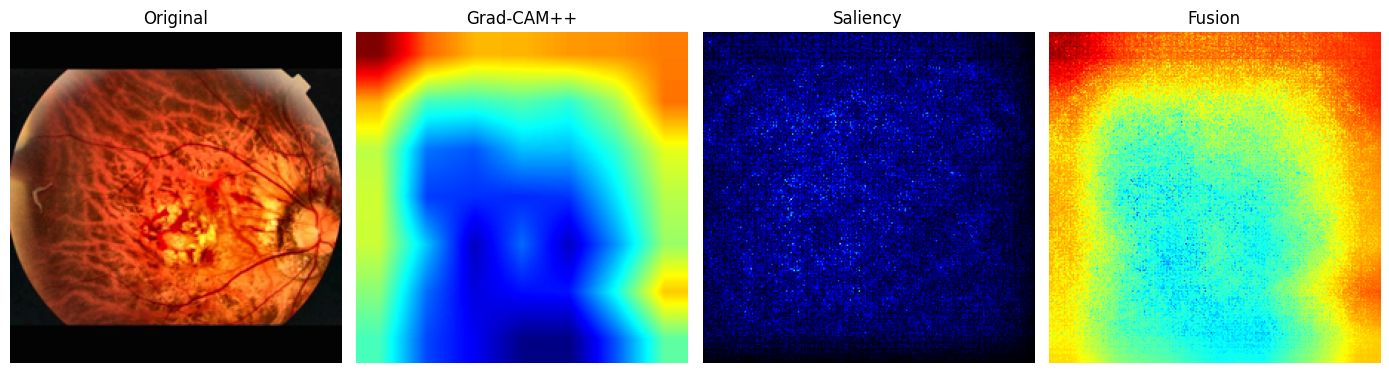

In [ ]:
# ================== ONE CELL : FINAL STABLE VERSION ==================
import os, cv2, joblib, torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from torchvision import models, transforms
from PIL import Image
from pathlib import Path

# ------------------ PATHS ------------------
MERGED_CSV  = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/merged_fundus_features.csv"
EXP_DIR     = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240"
FCNN_CKPT   = os.path.join(EXP_DIR,"fold2_FCNN_deep/FCNN_deep_fold2_best.pth")
SCALER_PATH = os.path.join(EXP_DIR,"scaler.joblib")
RESNET_CKPT = "/content/drive/MyDrive/Colab Notebooks/best_model_fold5.pth"
IMAGE_ROOT  = "/content/drive/MyDrive/Colab Notebooks/dataset_final_split"

CLASS_NAMES = ['hr','myopia','normal','rp']
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------ LOAD DATA ------------------
df = pd.read_csv(MERGED_CSV, low_memory=False)
df = df[~df['label_idx'].isna()].reset_index(drop=True)
df['label_idx'] = df['label_idx'].astype(int)

emb_cols = [c for c in df.columns if c.startswith("emb_")]
exclude = ['image_path','image_id','checkpoint_path','label_name','split','label_idx']
extra_numeric = [c for c in df.select_dtypes(include=np.number).columns
                 if c not in emb_cols + exclude]

FEATURE_COLS = emb_cols + extra_numeric
emb_dim = len(emb_cols)

scaler = joblib.load(SCALER_PATH)
X = df[FEATURE_COLS].replace([np.inf,-np.inf],np.nan)
X = X.fillna(X.mean()).fillna(0)
X_all = scaler.transform(X.values)

mean_full  = torch.tensor(scaler.mean_, dtype=torch.float32, device=device).unsqueeze(0)
scale_full = torch.tensor(scaler.scale_,dtype=torch.float32, device=device).unsqueeze(0)

df_test = df[df['split']=='test'].reset_index().rename(columns={'index':'orig_idx'})

# ------------------ FCNN (EXACT TRAINING ARCH) ------------------
class FCNN_deep(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 2048)
        self.bn1 = nn.BatchNorm1d(2048)
        self.fc2 = nn.Linear(2048, 1024)
        self.fc3 = nn.Linear(1024, 512)
        self.out = nn.Linear(512, num_classes)
        self.drop = nn.Dropout(0.4)

    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.drop(x)
        x = F.relu(self.fc2(x))
        x = self.drop(x)
        x = F.relu(self.fc3(x))
        x = self.drop(x)
        return self.out(x)

fcnn = FCNN_deep(len(FEATURE_COLS), len(CLASS_NAMES)).to(device)
fcnn.load_state_dict(torch.load(FCNN_CKPT, map_location=device), strict=True)
fcnn.eval()

# ------------------ RESNET ------------------
resnet = models.resnet18(weights=None)
resnet.fc = nn.Identity()
sd = torch.load(RESNET_CKPT, map_location="cpu")
sd = {k.replace("module.","").replace("model.",""):v for k,v in sd.items()}
resnet.load_state_dict(sd, strict=False)
resnet.eval().to(device)

tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# ------------------ IMAGE FINDER ------------------
def find_image(img_id):
    for sp in ['train','val','test']:
        for c in CLASS_NAMES:
            p = Path(IMAGE_ROOT)/sp/c
            if p.exists():
                f = list(p.glob(f"*{img_id}*"))
                if f:
                    return str(f[0])
    raise FileNotFoundError(img_id)

# ------------------ EXPLAIN FUNCTION ------------------
def explain(idx=160):
    r = df_test.iloc[idx]

    img = Image.open(find_image(r.image_id)).convert("RGB")
    img_t = tfms(img).unsqueeze(0).to(device)
    img_t.requires_grad_(True)

    clin = X_all[r.orig_idx][emb_dim:]
    clin = clin * scaler.scale_[emb_dim:] + scaler.mean_[emb_dim:]
    clin_t = torch.tensor(clin, dtype=torch.float32, device=device).unsqueeze(0)

    activations, gradients = None, None
    target = resnet.layer4[-1].conv2

    def fwd(m,i,o):
        nonlocal activations; activations = o
    def bwd(m,gi,go):
        nonlocal gradients; gradients = go[0]

    h1 = target.register_forward_hook(fwd)
    h2 = target.register_full_backward_hook(bwd)

    # forward
    x = img_t
    x = resnet.conv1(x); x = resnet.bn1(x); x = resnet.relu(x); x = resnet.maxpool(x)
    x = resnet.layer1(x); x = resnet.layer2(x)
    x = resnet.layer3(x); x = resnet.layer4(x)
    emb = torch.flatten(resnet.avgpool(x),1)

    full = torch.cat([emb, clin_t], 1)
    full = (full - mean_full) / (scale_full + 1e-6)

    out = fcnn(full)
    pred = out.argmax(1).item()

    fcnn.zero_grad(); resnet.zero_grad()
    out[0,pred].backward()

    h1.remove(); h2.remove()

    # ---------- GRAD-CAM++ ----------
    A = activations.detach()[0]   # (C,H,W)
    G = gradients.detach()[0]     # (C,H,W)

    alpha = G.pow(2) / (2*G.pow(2) + (A*G.pow(3)).sum((1,2),keepdim=True) + 1e-9)
    weights = (alpha * torch.relu(G)).sum((1,2))
    cam = torch.relu((weights[:,None,None] * A).sum(0))

    cam = cam.cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-9)
    cam = cv2.resize(cam, (224,224))
    cam_u8 = np.ascontiguousarray((cam * 255).astype(np.uint8))  # ✅ SAFE

    # ---------- SALIENCY ----------
    sal = img_t.grad.detach().abs().max(1)[0][0].cpu().numpy()
    sal = (sal - sal.min()) / (sal.max() - sal.min() + 1e-9)
    sal = cv2.resize(sal, (224,224))
    sal_u8 = np.ascontiguousarray((sal * 255).astype(np.uint8))   # ✅ SAFE

    # ---------- VISUALS ----------
    orig = np.array(img.resize((224,224)))

    gradcam = cv2.applyColorMap(cam_u8, cv2.COLORMAP_JET)
    salmap  = cv2.applyColorMap(sal_u8, cv2.COLORMAP_HOT)

    fusion_u8 = np.ascontiguousarray(
        (0.6 * cam + 0.4 * sal) * 255
    ).astype(np.uint8)
    fusion = cv2.applyColorMap(fusion_u8, cv2.COLORMAP_JET)

    fig, ax = plt.subplots(1,4, figsize=(14,4))
    for a,i,t in zip(
        ax,
        [orig, gradcam, salmap, fusion],
        ["Original", "Grad-CAM++", "Saliency", "Fusion"]
    ):
        a.imshow(i)
        a.axis("off")
        a.set_title(t)

    plt.tight_layout()
    plt.show()
# ------------------ RUN ------------------
explain(160)


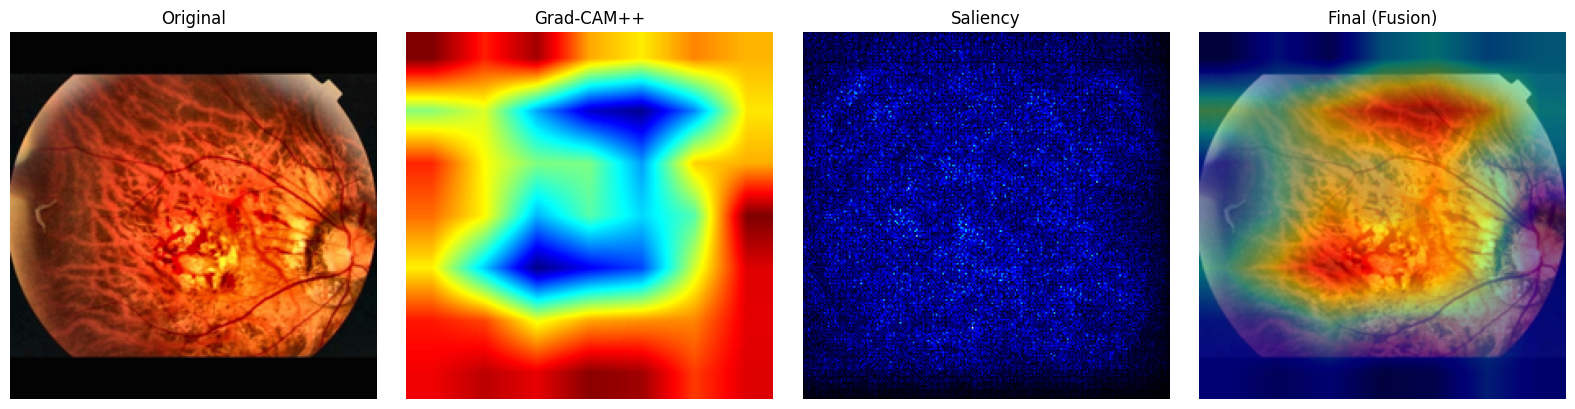

In [ ]:
# ===================== ONE CELL : EXPLAINABILITY =====================
import os, numpy as np, pandas as pd, joblib, torch, torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from pathlib import Path
from PIL import Image
import cv2, matplotlib.pyplot as plt, matplotlib.cm as cm

# ---------------- PATHS ----------------
MERGED_CSV  = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/merged_fundus_features.csv"
EXP_DIR     = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240"
FCNN_CKPT   = os.path.join(EXP_DIR,"fold2_FCNN_deep/FCNN_deep_fold2_best.pth")
SCALER_PATH = os.path.join(EXP_DIR,"scaler.joblib")
RESNET_CKPT = "/content/drive/MyDrive/Colab Notebooks/best_model_fold5.pth"
IMAGE_ROOT  = "/content/drive/MyDrive/Colab Notebooks/dataset_final_split"
OUT_DIR     = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/explainability"
os.makedirs(OUT_DIR, exist_ok=True)

CLASS_NAMES = ['hr','myopia','normal','rp']
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------- DATA ----------------
df = pd.read_csv(MERGED_CSV)
df = df.dropna(subset=["label_idx"]).reset_index(drop=True)
df["label_idx"] = df["label_idx"].astype(int)

emb_cols = [c for c in df.columns if c.startswith("emb_")]
exclude = ['image_path','image_id','checkpoint_path','label_name','split','label_idx']
extra_numeric = [c for c in df.select_dtypes(include=np.number).columns if c not in emb_cols+exclude]
FEATURE_COLS = emb_cols + extra_numeric
emb_dim = len(emb_cols)

scaler = joblib.load(SCALER_PATH)
X = df[FEATURE_COLS].replace([np.inf,-np.inf],np.nan)
X = X.fillna(X.mean()).fillna(0)
X_all = scaler.transform(X.values)

mean_full  = torch.tensor(scaler.mean_,dtype=torch.float32,device=device).unsqueeze(0)
scale_full = torch.tensor(scaler.scale_,dtype=torch.float32,device=device).unsqueeze(0)

df_test = df[df["split"]=="test"].reset_index().rename(columns={"index":"orig_idx"})

# ---------------- MODELS ----------------
class FCNN_deep(nn.Module):
    def __init__(self,d,c):
        super().__init__()
        self.fc1=nn.Linear(d,2048); self.bn1=nn.BatchNorm1d(2048)
        self.fc2=nn.Linear(2048,1024)
        self.fc3=nn.Linear(1024,512)
        self.out=nn.Linear(512,c)
        self.drop=nn.Dropout(0.4)
    def forward(self,x):
        x=F.relu(self.bn1(self.fc1(x))); x=self.drop(x)
        x=F.relu(self.fc2(x)); x=self.drop(x)
        x=F.relu(self.fc3(x)); x=self.drop(x)
        return self.out(x)

fcnn = FCNN_deep(len(FEATURE_COLS),len(CLASS_NAMES)).to(device)
fcnn.load_state_dict(torch.load(FCNN_CKPT,map_location=device))
fcnn.eval()

resnet = models.resnet18(weights=None)
resnet.fc = nn.Identity()
sd = torch.load(RESNET_CKPT,map_location="cpu")
sd = {k.replace("module.","").replace("model.",""):v for k,v in sd.items()}
resnet.load_state_dict(sd,strict=False)
resnet.eval().to(device)

tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

def find_image(img_id):
    for sp in ["train","val","test"]:
        for c in CLASS_NAMES:
            p=Path(IMAGE_ROOT)/sp/c
            if p.exists():
                f=list(p.glob(f"*{img_id}*"))
                if f: return str(f[0])
    raise FileNotFoundError(img_id)

# ---------------- EXPLAIN ----------------
def explain(idx=160):
    r=df_test.iloc[idx]
    img=Image.open(find_image(r.image_id)).convert("RGB")
    img_t=tfms(img).unsqueeze(0).to(device)

    clin=X_all[r.orig_idx][emb_dim:]
    clin=clin*scaler.scale_[emb_dim:]+scaler.mean_[emb_dim:]
    clin_t=torch.tensor(clin,dtype=torch.float32,device=device).unsqueeze(0)

    # hooks
    A=G=None
    def fwd(m,i,o): nonlocal A; A=o
    def bwd(m,gi,go): nonlocal G; G=go[0]
    h1=resnet.layer4[-1].conv2.register_forward_hook(fwd)
    h2=resnet.layer4[-1].conv2.register_full_backward_hook(bwd)

    # forward
    x=img_t
    x=resnet.conv1(x); x=resnet.bn1(x); x=resnet.relu(x); x=resnet.maxpool(x)
    x=resnet.layer1(x); x=resnet.layer2(x); x=resnet.layer3(x); x=resnet.layer4(x)
    emb=torch.flatten(resnet.avgpool(x),1)

    full=(torch.cat([emb,clin_t],1)-mean_full)/(scale_full+1e-6)
    out=fcnn(full)
    p=out.argmax(1).item()

    fcnn.zero_grad(); resnet.zero_grad()
    out[0,p].backward()
    h1.remove(); h2.remove()

    # -------- GradCAM++ --------
    A=A.detach()[0]; G=G.detach()[0]
    alpha=G.pow(2)/(2*G.pow(2)+(A*G.pow(3)).sum((1,2),keepdim=True)+1e-9)
    w=(alpha*torch.relu(G)).sum((1,2))
    cam=torch.relu((w[:,None,None]*A).sum(0)).cpu().numpy()
    cam=(cam-cam.min())/(cam.max()-cam.min()+1e-9)
    cam=cv2.resize(cam,(224,224))
    gradcam_only=cv2.applyColorMap((cam*255).astype(np.uint8),cv2.COLORMAP_JET)

    # -------- Saliency (image branch) --------
    img_s=img_t.clone().detach().requires_grad_(True)
    x=img_s
    x=resnet.conv1(x); x=resnet.bn1(x); x=resnet.relu(x); x=resnet.maxpool(x)
    x=resnet.layer1(x); x=resnet.layer2(x); x=resnet.layer3(x); x=resnet.layer4(x)
    emb_s=torch.flatten(resnet.avgpool(x),1)
    full_s=(torch.cat([emb_s,clin_t],1)-mean_full)/(scale_full+1e-6)
    out_s=fcnn(full_s)
    out_s[0,p].backward()

    sal=img_s.grad.abs().max(1)[0][0].cpu().numpy()
    sal=(sal-sal.min())/(sal.max()-sal.min()+1e-9)
    sal=cv2.resize(sal,(224,224))
    saliency_only=cv2.applyColorMap((sal*255).astype(np.uint8),cv2.COLORMAP_HOT)

    # -------- Final fusion (YOUR original logic) --------
    base=np.array(img.resize((224,224))).astype(np.float32)/255
    heat=cm.jet(cam)[...,:3]
    fusion=np.clip(0.55*base+0.45*heat,0,1)

    # -------- SHOW --------
    fig,ax=plt.subplots(1,4,figsize=(16,4))
    ax[0].imshow(base); ax[0].set_title("Original")
    ax[1].imshow(gradcam_only); ax[1].set_title("Grad-CAM++")
    ax[2].imshow(saliency_only); ax[2].set_title("Saliency")
    ax[3].imshow(fusion); ax[3].set_title("Final (Fusion)")
    for a in ax: a.axis("off")
    plt.tight_layout(); plt.show()

# ---------------- RUN ----------------
explain(160)


In [3]:
import torch
import torchvision.transforms as transforms
from torchvision import datasets, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Paths
RESNET_CKPT = "/content/drive/MyDrive/Colab Notebooks/best_model_fold5.pth"
IMAGE_ROOT  = "/content/drive/MyDrive/Colab Notebooks/dataset_final_split"

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transform
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load test dataset
test_dataset = datasets.ImageFolder(root=f"{IMAGE_ROOT}/test", transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class_names = test_dataset.classes
print("Classes:", class_names)

# Load model
model = models.resnet18(weights=None)
model.fc = torch.nn.Linear(model.fc.in_features, len(class_names))

checkpoint = torch.load(RESNET_CKPT, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

model.to(device)
model.eval()

# Inference
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:\n", cm)



Classes: ['hr', 'myopia', 'normal', 'rp']

Classification Report:

              precision    recall  f1-score   support

          hr       0.77      0.63      0.69       209
      myopia       0.95      0.93      0.94       380
      normal       0.77      0.86      0.81       399
          rp       1.00      1.00      1.00       169

    accuracy                           0.86      1157
   macro avg       0.87      0.86      0.86      1157
weighted avg       0.86      0.86      0.86      1157


Confusion Matrix:
 [[132   3  74   0]
 [  0 354  26   0]
 [ 39  17 343   0]
 [  0   0   0 169]]
